In [1]:
import datetime as dt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sqlite3
import warnings
from matplotlib.lines import Line2D

import sys
sys.path.append(r"C:\GitHubRepos\APSIMTools\GraphLib")

%load_ext autoreload
%autoreload 2

from pathlib import Path

# graph models
from apsim_tools.graphing import (
    plot_obs_pred_by_branch,
    plot_stage_timeseries
)

from apsim_tools.style import ( 
    Colors, 
    Markers,
    Lines
)

from apsim_tools.runner import (
    load_all,
    validate_run_branches,
    to_tidy
)

In [2]:
# import psutil
# print(psutil.virtual_memory())

In [3]:
warnings.filterwarnings('ignore',category=pd.errors.PerformanceWarning)

In [4]:
Colors = {1:'#000000',
2:'#E69F00',
3:'#56B4E9',
4:'#009E73',
5:'#F0E442',
6:'#0072B2',
7:'#D55E00',
8:'#CC79A7',
9:'#1F77B4',
10:'#AEC7E8',
11:'#FF7F0E',
12:'#FFBB78',
13:'#2CA02C',
14:'#98DF8A',
15:'#D62728',
16:'#FF9896',
17:'#9467BD',
18:'#C5B0D5',
19:'#8C564B',
20:'#C49C94',
21:'#E377C2',
22:'#F7B6D2',
23:'#7F7F7F',
24:'#C7C7C7',
25:'#BCBD22',
26:'#DBDB8D',
27:'#17BECF',
28:'#9EDAE5'}

Markers = {1: 'o',
 2: '^',
 3: 's',
 4: '*',
 5: '>',
 6: 'v',
 7: '+',
 8: 'X',
 9: '<',
 10: 'p',
 11: '8',
 12: 'd',
 13:'P',
 14:'D',
 15:'o',
 16:'^'}

Lines = {1: '-',
 2: '--',
 3: '-,',
 4: ':',
 5: '-',
 6: '--',
 7: '-,',
 8: ':',
 9: '-',
 10: '--',
 11: '-,',
 12: ':',
 13: '-',
 14: '--',
 15: '-,',
 16: ':'}

# Run all simulations to update

In [5]:
# ======================
# CONFIG
# ======================
BRANCHES = {
    "master": "UoM_Wheat",
    "working": "WheatNeil",
    "working V2": "WheatHamish"
}

# ======================
# RUN CONTROL - Specify which branches to (re)run
# ======================

# Options:
RUN_BRANCHES = []                    # run nothing (use existing DBs)
#RUN_BRANCHES = list(BRANCHES.keys())   # run all branches
#RUN_BRANCHES = ["master"]
#RUN_BRANCHES = ["working"]
#RUN_BRANCHES = ["working V2"]

SIM_FILES = [
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\Wheat.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\GxExM\GxExM.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\Pask\PaskExperiments.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\Dookie2024.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\Dookie2025.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\WaggaWagga2024.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\WaggaWagga2025.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\Gnarwarre2024.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\Gnarwarre2025.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\GrassPatch2024.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\GrassPatch2025.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\Fords2025.apsimx'),
    Path(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\Turretfield2024.apsimx')
]

CONFIG = {
    "branches": BRANCHES,
    "run_branches": RUN_BRANCHES,
    "sim_files": SIM_FILES,
    "repo_path": Path(r"C:\GitHubRepos\ApsimX"),
    "apsim_exe": r"C:\GitHubRepos\ApsimX\bin\Release\net8.0\Models.exe",
    "apsim_solution": r"C:\GitHubRepos\ApsimX\ApsimX.sln",
    "stage_var": "Wheat.Phenology.Stage",
    "stage_name_var": "Wheat.Phenology.CurrentStageName",
    "harvest_stage": "HarvestRipe",
    "cultivar_col": "Wheat.SowingData.Cultivar"
}

In [6]:
# this function writes and apply file that the CLI
def write_apply_file(sim_file):
    """
    Create an APSIM CLI apply file which:
    - removes specified reports
    - injects AnalysisReport
    - sets variables
    - saves and runs simulation
    """
    report_library = r"C:\GitHubRepos\APSIMTools\Report_lib.apsimx"
    apply_file = sim_file.with_name(f"_apply_{sim_file.stem}.txt")

    lines = []

    # ---------------------------------------------
    # Add AnalysisReport to all Simulation nodes
    # ---------------------------------------------
    lines.append("delete all [Report]")
    lines.append(f"add [ObsAnalysisReport] from {report_library} to all [Zone]")

    # ---------------------------------------------
    # Remove existing ObsPred table and add HarvestObsPred to data store
    # ---------------------------------------------
    lines.append("delete all [PredictedObserved]")
    
    lines.append("add new PredictedObserved to [DataStore] name HarvestObsPred")
    lines.append("[HarvestObsPred].PredictedTableName  = AnalysisReport")
    lines.append("[HarvestObsPred].ObservedTableName  = Observed")
    lines.append("[HarvestObsPred].FieldNameUsedForMatch  = SimulationName")
    lines.append("[HarvestObsPred].FieldName2UsedForMatch  = Wheat.Phenology.CurrentStageName")
        
    lines.append("add new PredictedObserved to DataStore name DailyObsPred")
    lines.append("[DailyObsPred].PredictedTableName  = AnalysisReport")
    lines.append("[DailyObsPred].ObservedTableName  = Observed")
    lines.append("[DailyObsPred].FieldNameUsedForMatch  = SimulationName")
    lines.append("[DailyObsPred].FieldName2UsedForMatch  = Clock.Today")
    
    # ---------------------------------------------
    # Inject Spectral model into each simulation
    # ---------------------------------------------
    lines.append("delete all [Spectral]")
    lines.append("add new Spectral to all [Zone]")

    # ---------------------------------------------
    # Save + run
    # ---------------------------------------------
    lines.append(f"save {sim_file}")
    lines.append(f"run")

    # Write file
    apply_file.write_text("\n".join(lines))

    return apply_file

## Additional indexes

In [7]:
DevMap = {
"Accroc":"Winter",
"Adv08_0008":"Winter",
"Anapurna":"Winter",
"Ararat":"Spring",
"Atlanta":"Spring",
"Axe":"Spring",
"Batavia":"Spring",
"Battenspring":"Spring",
"Batten":"Winter",
"Beaufort":"Spring",
"Bennett":"Winter",
"Bigred":"Winter",
"Bolac":"Spring",
"Braewood":"Spring",
"Calabro":"Winter",
"Calingiri":"Spring",
"Catalina":"Spring",
"Catapult":"Spring",
"Cesario":"Winter",
"Claire":"Winter",
"Conquest":"Spring",
"Corack":"Spring",
"Crusader":"Spring",
"Crw247":"Spring",
"Cutlass":"Spring",
"Dekan":"Spring",
"Derrimut":"Spring",
"Discovery":"Spring",
"Drysdale":"Spring",
"Eaglehawk":"Spring",
"Einstein":"Winter",
"Ellison":"Spring",
"Forrest":"Spring",
"Gamenya":"Spring",
"Gauntlet":"Spring",
"Gladius":"Spring",
"Gorgan":"Spring",
"Graham":"Winter",
"Gregory":"Spring",
"Gutha":"Spring",
"H45":"Spring",
"H46":"Spring",
"Har1685":"Spring",
"Hartog":"Spring",
"Hume":"Spring",
"Illabo":"Winter",
"Istabraq":"Spring",
"Janz":"Spring",
"Kellalac":"Spring",
"Kennedy":"Spring",
"Kerrin":"Winter",
"Keyu13":"Spring",
"Kinsei":"Spring",
"Kittyhawk":"Winter",
"Konya":"Spring",
"Lancer":"Spring",
"Lincoln":"Spring",
"Livingston":"Spring",
"Mace":"Spring",
"Magenta":"Spring",
"Manning":"Winter",
"Matong":"Spring",
"Meering":"Spring",
"Mercury":"Spring",
"Merinda":"Spring",
"Mowhawk":"Winter",
"Nighthawk":"Spring",
"Osprey":"Winter",
"Otane":"Spring",
"Ouyen":"Spring",
"Pascal":"Spring",
"Peake":"Spring",
"Relay":"Winter",
"Revenue":"Winter",
"Rockstar":"Spring",
"Rongotea":"Spring",
"Rosario":"Spring",
"Rosella":"Winter",
"Ruby":"Spring",
"Savannah":"Winter",
"Scepter":"Spring",
"Scout":"Spring",
"Scythe":"Spring",
"Sorrial":"Winter",
"Spear":"Spring",
"Spitfire":"Spring",
"Stockade":"Spring",
"Strzelecki":"Spring",
"Sunbri":"Spring",
"Sunmaster":"Spring",
"Sunstate":"Spring",
"Suntop":"Spring",
"Trojan":"Spring",
"Uom001_3_47":"Winter",
"Uom001_9_1":"Winter",
"Ventura":"Spring",
"Voltron":"Winter",
"Wakanui":"Winter",
"Waugh":"Winter",
"Wedgetail":"Winter",
"Whistler":"Winter",
"Wilgoyne":"Spring",
"Wills":"Spring",
"Wyalkatchem":"Spring",
"Wylah":"Winter",
"Yecora":"Spring",
"Yitpi":"Spring",
"Young":"Spring",
"Zanzibar":"Spring",
"Zyatt":"Winter",
}

TestSetMap = {
'APS14':'TestSet',
'APS26':'TestSet',
'APS2':'TestSet',
'APS6':'TestSet',
'Cunderdin97':'TestSet',
'Gatton2009':'TestSet',
'Gatton2009TOS1CvKelallac':'TestSet',
'Gatton2009TOS1CvMckellar':'TestSet',
'Gatton2009TOS2CvKelallac':'TestSet',
'Gatton2009TOS2CvMckellar':'TestSet',
'Gatton2009TOS3CvKelallac':'TestSet',
'Gatton2009TOS3CvMckellar':'TestSet',
'Gatton2011':'TestSet',
'Gatton2011TOS2CvEaglehawk':'TestSet',
'Gatton2014AE':'TestSet',
'Gatton2014AEV1P1CvBaxter':'TestSet',
'Gatton2014AEV1P1CvDrysdale':'TestSet',
'Gatton2014AEV1P1CvHartog':'TestSet',
'Gatton2014AEV1P1CvWestonia':'TestSet',
'Gatton2014AEV1P2CvBaxter':'TestSet',
'Gatton2014AEV1P2CvDrysdale':'TestSet',
'Gatton2014AEV1P2CvHartog':'TestSet',
'Gatton2014AEV1P2CvWestonia':'TestSet',
'Gatton2014AEV2P1CvBaxter':'TestSet',
'Gatton2014AEV2P1CvDrysdale':'TestSet',
'Gatton2014AEV2P1CvHartog':'TestSet',
'Gatton2014AEV2P1CvWestonia':'TestSet',
'Gatton2014AEV2P2CvBaxter':'TestSet',
'Gatton2014AEV2P2CvDrysdale':'TestSet',
'Gatton2014AEV2P2CvHartog':'TestSet',
'Gatton2014AEV2P2CvWestonia':'TestSet',
'Gatton2014':'TestSet',
'Gatton2014TOS11-AprCvBaxter':'TestSet',
'Gatton2014TOS11-AprCvDrysdale':'TestSet',
'Gatton2014TOS11-AprCvHartog':'TestSet',
'Gatton2014TOS11-AprCvWestonia':'TestSet',
'Gatton2014TOS12-AugCvBaxter':'TestSet',
'Gatton2014TOS12-AugCvDrysdale':'TestSet',
'Gatton2014TOS12-AugCvHartog':'TestSet',
'Gatton2014TOS12-AugCvWestonia':'TestSet',
'Gatton2014TOS13-MayCvBaxter':'TestSet',
'Gatton2014TOS13-MayCvDrysdale':'TestSet',
'Gatton2014TOS13-MayCvHartog':'TestSet',
'Gatton2014TOS13-MayCvWestonia':'TestSet',
'Gatton2014TOS16-JulCvBaxter':'TestSet',
'Gatton2014TOS16-JulCvDrysdale':'TestSet',
'Gatton2014TOS16-JulCvHartog':'TestSet',
'Gatton2014TOS16-JulCvWestonia':'TestSet',
'Gatton94':'TestSet',
'Gatton94CvBataviaTOS4_Jul':'TestSet',
'Gatton94CvHartogTOS4_Jul':'TestSet',
'GattonRowSpacing':'TestSet',
'Ginninderra1991':'TestSet',
'Gorgan05':'TestSet',
'Griffith1983CVYecoraTOS15-Apr':'TestSet',
'Jamma':'TestSet',
'Konya09':'TestSet',
'Konya11':'TestSet',
'Leeston2013':'TestSet',
'Leeston2014':'TestSet',
'Lincoln1991':'TestSet',
'Lincoln1991Irrig02':'TestSet',
'Lincoln1991Irrig04':'TestSet',
'Lincoln1991Irrig09':'TestSet',
'Lincoln1991Irrig10':'TestSet',
'Lincoln1991Irrig12':'TestSet',
'Lincoln1991Irrig13':'TestSet',
'Lincoln1991Irrig14':'TestSet',
'Lincoln1992':'TestSet',
'Lincoln1994':'TestSet',
'Lincoln2010':'TestSet',
'Lincoln2014':'TestSet',
'Lincoln2015':'TestSet',
'Lincoln2021':'TestSet',
'Lincoln2023':'TestSet',
'Lincoln2024':'TestSet',
'Linconln2015Nit0IrrFull':'TestSet',
'Linconln2015Nit0IrrNil':'TestSet',
'Linconln2015Nit250IrrFull':'TestSet',
'Linconln2015Nit250IrrNil':'TestSet',
'Linconln2015Nit50IrrFull':'TestSet',
'Linconln2015Nit50IrrNil':'TestSet',
'Lonzee04':'TestSet',
'Lonzee06':'TestSet',
'Lonzee08':'TestSet',
'MaricopaFACE92_93':'TestSet',
'MaricopaFACE93_94':'TestSet',
'MaricopaFACE95_96':'TestSet',
'MaricopaFACE96_97':'TestSet',
'Mer73':'TestSet',
'Mer86':'TestSet',
'Mouse':'TestSet',
'PalmerstonNorth1989':'TestSet',
'TraitMod2015':'TestSet',
'TraitMod2016':'TestSet',
'Wagga1991':'TestSet',
'Wagga2013':'TestSet',
'Wagga2014':'TestSet',
'Wakanui2015':'TestSet',
'Wakanui2016':'TestSet',
'Wakanui2017':'TestSet',
'Wheat_Beverley90_Early':'TestSet',
'Wheat_Beverley90_Late':'TestSet',
'Wheat_Beverley90_n15':'TestSet',
'Wheat_Beverley90_n30':'TestSet',
'Wheat_Beverley90_n60':'TestSet',
'Wheat_Corrigin_10mmBasal':'TestSet',
'Wheat_Corrigin_10mmBasalTopDress':'TestSet',
'Wheat_Corrigin_40mmBasal':'TestSet',
'Wheat_Corrigin_40mmBasalTopDress':'TestSet',
'Wheat_Corrigin_DryBasal':'TestSet',
'Wheat_Corrigin_DryBasalTopDress':'TestSet',
'Wheat_Moora94_N0':'TestSet',
'Wheat_Moora94_N50':'TestSet',
'Wheat_Moora95_N0':'TestSet',
'Wheat_Moora95_N80':'TestSet',
'Wheat_Wongan83_Single':'TestSet',
'Wheat_Wongan84_N000':'TestSet',
'Wheat_Wongan84_N050':'TestSet',
'Wheat_Wongan84_N300':'TestSet',
'Wheat_Wongan84_N325':'TestSet',
'Wongan83':'TestSet',
'YarrabahCreek':'TestSet',
'Yucheng02':'TestSet',
'Yucheng03':'TestSet',
'Yucheng04':'TestSet',
'AGR ESW W23-01':'FAR',
'AGR ESW W23-01TOS1CvLancer':'FAR',
'AGR ESW W23-01TOS1CvLongsword':'FAR',
'AGR ESW W23-01TOS1CvRaider':'FAR',
'AGR ESW W23-01TOS1CvSunmaster':'FAR',
'AGR ESW W23-01TOS1CvVixen':'FAR',
'AGR ESW W23-01TOS2CvLancer':'FAR',
'AGR ESW W23-01TOS2CvLongsword':'FAR',
'AGR ESW W23-01TOS2CvRaider':'FAR',
'AGR ESW W23-01TOS2CvSunmaster':'FAR',
'AGR ESW W23-01TOS2CvVixen':'FAR',
'FAR DMC W20-03':'FAR',
'FAR DMC W20-03MgmtGrazedCvTabasco':'FAR',
'FAR DMC W20-03MgmtHigh InputCvTabasco':'FAR',
'FAR DMC W20-03MgmtStandardCvTabasco':'FAR',
'FAR DMC W20-05':'FAR',
'FAR DMC W20-06':'FAR',
'FAR ESW W23-02':'FAR',
'FAR ESW W23-02GrazeGrazeSeed180CvLongsword':'FAR',
'FAR ESW W23-02GrazeGrazeSeed180CvRaider':'FAR',
'FAR ESW W23-02GrazeGrazeSeed30CvLongsword':'FAR',
'FAR ESW W23-02GrazeGrazeSeed30CvRaider':'FAR',
'FAR ESW W23-02GrazeGrazeSeed90CvLongsword':'FAR',
'FAR ESW W23-02GrazeGrazeSeed90CvRaider':'FAR',
'FAR ESW W23-02GrazeNoneSeed180CvLongsword':'FAR',
'FAR ESW W23-02GrazeNoneSeed180CvRaider':'FAR',
'FAR ESW W23-02GrazeNoneSeed30CvLongsword':'FAR',
'FAR ESW W23-02GrazeNoneSeed30CvRaider':'FAR',
'FAR ESW W23-02GrazeNoneSeed90CvLongsword':'FAR',
'FAR ESW W23-02GrazeNoneSeed90CvRaider':'FAR',
'FAR HYC W17-01-1':'FAR',
'FAR HYC W17-01-1MgmtGrazedCvConqueror':'FAR',
'FAR HYC W17-01-1MgmtGrazedCvGenius':'FAR',
'FAR HYC W17-01-1MgmtHigh InputCvConqueror':'FAR',
'FAR HYC W17-01-1MgmtHigh InputCvGenius':'FAR',
'FAR HYC W17-01-1MgmtStandardCvConqueror':'FAR',
'FAR HYC W17-01-1MgmtStandardCvGenius':'FAR',
'FAR HYC W17-01-2MgmtHigh InputCvADV11.9419':'FAR',
'FAR HYC W17-01-2MgmtHigh InputCvAGTW0001':'FAR',
'FAR HYC W17-01-2MgmtHigh InputCvAGTW0002':'FAR',
'FAR HYC W17-01-2':'FAR',
'FAR HYC W17-01-2MgmtHigh InputCvConqueror':'FAR',
'FAR HYC W17-01-2MgmtHigh InputCvGenius':'FAR',
'FAR HYC W17-01-2MgmtStandardCvADV11.9419':'FAR',
'FAR HYC W17-01-2MgmtStandardCvAGTW0001':'FAR',
'FAR HYC W17-01-2MgmtStandardCvAGTW0002':'FAR',
'FAR HYC W17-01-2MgmtStandardCvConqueror':'FAR',
'FAR HYC W17-01-2MgmtStandardCvGenius':'FAR',
'FAR HYC W17-02-1CvAGTW0001':'FAR',
'FAR HYC W17-02-1':'FAR',
'FAR HYC W17-02-1CvAsano':'FAR',
'FAR HYC W17-02-1CvBA 26.35':'FAR',
'FAR HYC W17-02-1CvConqueror':'FAR',
'FAR HYC W17-02-1CvCordiale':'FAR',
'FAR HYC W17-02-1CvGenius':'FAR',
'FAR HYC W17-02-1CvHereford':'FAR',
'FAR HYC W17-02-1CvMercedes':'FAR',
'FAR HYC W17-02-1CvOakley':'FAR',
'FAR HYC W17-02-1CvViscount':'FAR',
'FAR HYC W17-02-1CvXi19':'FAR',
'FAR HYC W17-02-2CvADV14.1292':'FAR',
'FAR HYC W17-02-2CvADV14.1335':'FAR',
'FAR HYC W17-02-2':'FAR',
'FAR HYC W17-02-2CvApache':'FAR',
'FAR HYC W17-02-2CvAsano':'FAR',
'FAR HYC W17-02-2CvBA 26.35':'FAR',
'FAR HYC W17-02-2CvCS170':'FAR',
'FAR HYC W17-02-2CvCS3250.30':'FAR',
'FAR HYC W17-02-2CvCS611':'FAR',
'FAR HYC W17-02-2CvCS98152.79':'FAR',
'FAR HYC W17-02-2CvCSQ496.88':'FAR',
'FAR HYC W17-02-2CvCSR65':'FAR',
'FAR HYC W17-02-2CvCordiale':'FAR',
'FAR HYC W17-02-2CvEDGE W12-090-04':'FAR',
'FAR HYC W17-02-2CvEDGE06-018b-10':'FAR',
'FAR HYC W17-02-2CvHereford':'FAR',
'FAR HYC W17-02-2CvKowari (Trit)':'FAR',
'FAR HYC W17-02-2CvOakley':'FAR',
'FAR HYC W17-02-2CvSolist':'FAR',
'FAR HYC W17-02-2CvTabasco':'FAR',
'FAR HYC W17-02-2CvTuareg':'FAR',
'FAR HYC W17-02-2CvViscount':'FAR',
'FAR HYC W17-02-2CvXi19':'FAR',
'FAR HYC W17-08':'FAR',
'FAR HYC W18-02-1':'FAR',
'FAR HYC W18-02-2':'FAR',
'FAR HYC W18-02-2Seeds100CvBennett':'FAR',
'FAR HYC W18-02-2Seeds175CvBennett':'FAR',
'FAR HYC W18-02-2Seeds250CvBennett':'FAR',
'FAR HYC W18-02-2a':'FAR',
'FAR HYC W18-08-1':'FAR',
'FAR HYC W19-01-1':'FAR',
'FAR HYC W19-01-1FungicideFullCvConqueror':'FAR',
'FAR HYC W19-01-1FungicideFullCvGenius':'FAR',
'FAR HYC W19-01-1FungicideFullCvTabasco':'FAR',
'FAR HYC W19-01-1FungicideNoneCvConqueror':'FAR',
'FAR HYC W19-01-1FungicideNoneCvGenius':'FAR',
'FAR HYC W19-01-1FungicideNoneCvTabasco':'FAR',
'FAR HYC W19-02-1':'FAR',
'FAR HYC W19-03-1GrazedGS16 30 40NSeeds100CvBennett':'FAR',
'FAR HYC W19-03-1GrazedGS16 30 40NSeeds175CvBennett':'FAR',
'FAR HYC W19-03-1GrazedGS16 30 40NSeeds250CvBennett':'FAR',
'FAR HYC W19-03-1GrazedGS16 30Seeds100CvBennett':'FAR',
'FAR HYC W19-03-1GrazedGS16 30Seeds175CvBennett':'FAR',
'FAR HYC W19-03-1GrazedGS16 30Seeds250CvBennett':'FAR',
'FAR HYC W19-03-1GrazedGS16Seeds100CvBennett':'FAR',
'FAR HYC W19-03-1GrazedGS16Seeds175CvBennett':'FAR',
'FAR HYC W19-03-1GrazedGS16Seeds250CvBennett':'FAR',
'FAR HYC W19-06-1':'FAR',
'FAR HYC W19-08-1':'FAR',
'FAR NEV FRO WB23-01':'FAR',
'FAR NEV FRO WB23-01Def1TOS1CvVixen':'FAR',
'FAR NEV FRO WB23-01Def1TOS2CvVixen':'FAR',
'FAR NEV FRO WB23-01Def2TOS1CvVixen':'FAR',
'FAR NEV FRO WB23-01Def2TOS2CvVixen':'FAR',
'FAR NEV FRO WB23-01DefControlTOS1CvDenison':'FAR',
'FAR NEV FRO WB23-01DefControlTOS1CvVixen':'FAR',
'FAR NEV FRO WB23-01DefControlTOS2CvDenison':'FAR',
'FAR NEV FRO WB23-01DefControlTOS2CvVixen':'FAR',
'FAR NEV FRO WB23-01DefControlTOS3CvDenison':'FAR',
'FAR NEV FRO WB23-01DefControlTOS3CvVixen':'FAR',
'FAR NSW W23-03MgmtHigh InputCvAGTW0005':'FAR',
'FAR NSW W23-03':'FAR',
'FAR NSW W23-03MgmtHigh InputCvLongford':'FAR',
'FAR NSW W23-03MgmtLow InputCvAGTW0005':'FAR',
'FAR NSW W23-03MgmtLow InputCvLongford':'FAR',
'FAR NSW W23-03MgmtStrategicCvAGTW0005':'FAR',
'FAR NSW W23-03MgmtStrategicCvLongford':'FAR',
'FAR NSW W23-03MgmtTacticalCvAGTW0005':'FAR',
'FAR NSW W23-03MgmtTacticalCvLongford':'FAR',
'FAR NSW W23-05':'FAR',
'FAR RRC W20-03':'FAR',
'FAR RRC W20-03MgmtGrazedCvBeckom':'FAR',
'FAR RRC W20-03MgmtGrazedCvGregory':'FAR',
'FAR RRC W20-03MgmtHigh InputCvBeckom':'FAR',
'FAR RRC W20-03MgmtHigh InputCvGregory':'FAR',
'FAR RRC W20-03MgmtStandardCvBeckom':'FAR',
'FAR RRC W20-03MgmtStandardCvGregory':'FAR',
'FAR RRC W20-05':'FAR',
'FAR RRC W20-06-1':'FAR',
'FAR RRC W21-01CvAGFWH004418':'FAR',
'FAR RRC W21-01CvAGFWH004618':'FAR',
'FAR RRC W21-01':'FAR',
'FAR RRC W21-01CvAurora':'FAR',
'FAR RRC W21-01CvBeckom':'FAR',
'FAR RRC W21-01CvBitalli':'FAR',
'FAR RRC W21-01CvCoota':'FAR',
'FAR RRC W21-01CvGraham':'FAR',
'FAR RRC W21-01CvL13070-027':'FAR',
'FAR RRC W21-01CvLPB16-0582':'FAR',
'FAR RRC W21-01CvLPB17-5691':'FAR',
'FAR RRC W21-01CvLongford':'FAR',
'FAR RRC W21-01CvReflection':'FAR',
'FAR RRC W21-01CvSUN1087I':'FAR',
'FAR RRC W21-01CvSavello':'FAR',
'FAR RRC W21-01CvShabras':'FAR',
'FAR RRC W21-01CvTabasco':'FAR',
'FAR RRC W21-01CvV11068-085-047':'FAR',
'FAR RRC W21-01CvV12167-048':'FAR',
'FAR RRC W21-01CvWestcourt':'FAR',
'FAR RRC W21-03':'FAR',
'FAR RRC W21-06':'FAR',
'FAR RRC W21-07':'FAR',
'FAR RRC W22-02FungicideFullCvAGTW0005':'FAR',
'FAR RRC W22-02':'FAR',
'FAR RRC W22-02FungicideFullCvLongford':'FAR',
'FAR RRC W22-02FungicideFullCvReflection':'FAR',
'FAR RRC W22-02FungicideFullCvTabasco':'FAR',
'FAR RRC W22-02FungicideNoneCvAGTW0005':'FAR',
'FAR RRC W22-02FungicideNoneCvLongford':'FAR',
'FAR RRC W22-02FungicideNoneCvReflection':'FAR',
'FAR RRC W22-03':'FAR',
'FAR RRC W22-05-1':'FAR',
'FAR SAC W18-01MgmtGrazedCvAGTW0002':'FAR',
'FAR SAC W18-01':'FAR',
'FAR SAC W18-01MgmtGrazedCvConqueror':'FAR',
'FAR SAC W18-01MgmtHigh InputCvAGTW0002':'FAR',
'FAR SAC W18-01MgmtHigh InputCvConqueror':'FAR',
'FAR SAC W18-01MgmtStandardCvAGTW0002':'FAR',
'FAR SAC W18-01MgmtStandardCvConqueror':'FAR',
'FAR SAC W18-02':'FAR',
'FAR SAC W18-02FungicideNoneCvAdagio':'FAR',
'FAR SAC W18-02FungicideNoneCvAsano':'FAR',
'FAR SAC W18-02FungicideNoneCvCoolah':'FAR',
'FAR SAC W18-02FungicideNoneCvGenius':'FAR',
'FAR SAC W18-02FungicideNoneCvHereford':'FAR',
'FAR SAC W18-02FungicidePlusCvAdagio':'FAR',
'FAR SAC W18-02FungicidePlusCvAsano':'FAR',
'FAR SAC W18-02FungicidePlusCvCoolah':'FAR',
'FAR SAC W18-02FungicidePlusCvGenius':'FAR',
'FAR SAC W18-02FungicidePlusCvHereford':'FAR',
'FAR SAC W18-06':'FAR',
'FAR SAC W19-01':'FAR',
'FAR SAC W19-01MgmtGrazedCvConqueror':'FAR',
'FAR SAC W19-01MgmtGrazedCvTabasco':'FAR',
'FAR SAC W19-01MgmtHigh InputCvConqueror':'FAR',
'FAR SAC W19-01MgmtHigh InputCvTabasco':'FAR',
'FAR SAC W19-01MgmtStandardCvConqueror':'FAR',
'FAR SAC W19-01MgmtStandardCvTabasco':'FAR',
'FAR SAC W19-02':'FAR',
'FAR SAC W19-02FungicideFullCvAdagio':'FAR',
'FAR SAC W19-02FungicideFullCvAsano':'FAR',
'FAR SAC W19-02FungicideFullCvHereford':'FAR',
'FAR SAC W19-02FungicideFullCvTabasco':'FAR',
'FAR SAC W19-02FungicideNoneCvAdagio':'FAR',
'FAR SAC W19-02FungicideNoneCvAsano':'FAR',
'FAR SAC W19-02FungicideNoneCvHereford':'FAR',
'FAR SAC W19-02FungicideNoneCvTabasco':'FAR',
'FAR SAC W19-06':'FAR',
'FAR SAC W20-03-1':'FAR',
'FAR SAC W20-03-1MgmtGrazedCvAdagio':'FAR',
'FAR SAC W20-03-1MgmtGrazedCvTabasco':'FAR',
'FAR SAC W20-03-1MgmtHigh InputCvAdagio':'FAR',
'FAR SAC W20-03-1MgmtHigh InputCvTabasco':'FAR',
'FAR SAC W20-03-1MgmtStandardCvAdagio':'FAR',
'FAR SAC W20-03-1MgmtStandardCvTabasco':'FAR',
'FAR SAC W20-03-2':'FAR',
'FAR SAC W20-03-2MgmtHigh InputCvCobra':'FAR',
'FAR SAC W20-03-2MgmtLow InputCvCobra':'FAR',
'FAR SAC W20-03-2MgmtStandardCvCobra':'FAR',
'FAR SAC W20-05-1':'FAR',
'FAR SAC W20-06-1':'FAR',
'FAR SAC W21-05-1':'FAR',
'FAR SAC W22-03-1':'FAR',
'FAR SAC W22-03-2':'FAR',
'FAR SAC W22-05-1':'FAR',
'FAR SAC W23-05':'FAR',
'FAR TAS W16-01-1MgmtGrazedCvADV11.9419':'FAR',
'FAR TAS W16-01-1':'FAR',
'FAR TAS W16-01-1MgmtGrazedCvCS3250.30':'FAR',
'FAR TAS W16-01-1MgmtGrazedCvCS98152.79':'FAR',
'FAR TAS W16-01-1MgmtGrazedCvCSQ496.88':'FAR',
'FAR TAS W16-01-1MgmtGrazedCvConqueror':'FAR',
'FAR TAS W16-01-1MgmtGrazedCvEDGE06-018b-10':'FAR',
'FAR TAS W16-01-1MgmtGrazedCvEDGE06-025-03':'FAR',
'FAR TAS W16-01-1MgmtGrazedCvEDGE06-039-13':'FAR',
'FAR TAS W16-01-1MgmtGrazedCvGenius':'FAR',
'FAR TAS W16-01-1MgmtGrazedCvLPB11-0140':'FAR',
'FAR TAS W16-01-1MgmtGrazedCvV08126-64':'FAR',
'FAR TAS W16-01-1MgmtGrazedCvV10006-026':'FAR',
'FAR TAS W16-01-1MgmtGrazedCvV10083-050':'FAR',
'FAR TAS W16-01-1MgmtHigh InputCvADV11.9419':'FAR',
'FAR TAS W16-01-1MgmtHigh InputCvCS3250.30':'FAR',
'FAR TAS W16-01-1MgmtHigh InputCvCS98152.79':'FAR',
'FAR TAS W16-01-1MgmtHigh InputCvCSQ496.88':'FAR',
'FAR TAS W16-01-1MgmtHigh InputCvConqueror':'FAR',
'FAR TAS W16-01-1MgmtHigh InputCvEDGE06-018b-10':'FAR',
'FAR TAS W16-01-1MgmtHigh InputCvEDGE06-025-03':'FAR',
'FAR TAS W16-01-1MgmtHigh InputCvEDGE06-039-13':'FAR',
'FAR TAS W16-01-1MgmtHigh InputCvGenius':'FAR',
'FAR TAS W16-01-1MgmtHigh InputCvLPB11-0140':'FAR',
'FAR TAS W16-01-1MgmtHigh InputCvV08126-64':'FAR',
'FAR TAS W16-01-1MgmtHigh InputCvV10006-026':'FAR',
'FAR TAS W16-01-1MgmtHigh InputCvV10083-050':'FAR',
'FAR TAS W16-01-2MgmtHigh InputCvADV11.9419':'FAR',
'FAR TAS W16-01-2':'FAR',
'FAR TAS W16-01-2MgmtHigh InputCvCS3250.30':'FAR',
'FAR TAS W16-01-2MgmtHigh InputCvCS98152.79':'FAR',
'FAR TAS W16-01-2MgmtHigh InputCvCSQ496.88':'FAR',
'FAR TAS W16-01-2MgmtHigh InputCvConqueror':'FAR',
'FAR TAS W16-01-2MgmtHigh InputCvEDGE06-018b-10':'FAR',
'FAR TAS W16-01-2MgmtHigh InputCvEDGE06-025-03':'FAR',
'FAR TAS W16-01-2MgmtHigh InputCvEDGE06-039-13':'FAR',
'FAR TAS W16-01-2MgmtHigh InputCvGenius':'FAR',
'FAR TAS W16-01-2MgmtHigh InputCvLPB11-0140':'FAR',
'FAR TAS W16-01-2MgmtHigh InputCvV08126-64':'FAR',
'FAR TAS W16-01-2MgmtHigh InputCvV10006-026':'FAR',
'FAR TAS W16-01-2MgmtHigh InputCvV10083-050':'FAR',
'FAR TAS W16-01-2MgmtStandardCvADV11.9419':'FAR',
'FAR TAS W16-01-2MgmtStandardCvCS3250.30':'FAR',
'FAR TAS W16-01-2MgmtStandardCvCS98152.79':'FAR',
'FAR TAS W16-01-2MgmtStandardCvCSQ496.88':'FAR',
'FAR TAS W16-01-2MgmtStandardCvConqueror':'FAR',
'FAR TAS W16-01-2MgmtStandardCvEDGE06-018b-10':'FAR',
'FAR TAS W16-01-2MgmtStandardCvEDGE06-025-03':'FAR',
'FAR TAS W16-01-2MgmtStandardCvEDGE06-039-13':'FAR',
'FAR TAS W16-01-2MgmtStandardCvGenius':'FAR',
'FAR TAS W16-01-2MgmtStandardCvLPB11-0140':'FAR',
'FAR TAS W16-01-2MgmtStandardCvV08126-64':'FAR',
'FAR TAS W16-01-2MgmtStandardCvV10006-026':'FAR',
'FAR TAS W16-01-2MgmtStandardCvV10083-050':'FAR',
'FAR TAS W16-06':'FAR',
'FAR TAS W16-06PGRDoubleLateSeeds200CvManning':'FAR',
'FAR TAS W16-06PGRDoubleMidSeeds200CvManning':'FAR',
'FAR TAS W16-06PGREarly1Seeds200CvManning':'FAR',
'FAR TAS W16-06PGREarly2Seeds200CvManning':'FAR',
'FAR TAS W16-06PGRNoneSeeds100CvManning':'FAR',
'FAR TAS W16-06PGRNoneSeeds150CvManning':'FAR',
'FAR TAS W16-06PGRNoneSeeds200CvManning':'FAR',
'FAR TAS W16-06PGRNoneSeeds50CvManning':'FAR',
'FAR TAS W16-06PGRSingleLateSeeds200CvManning':'FAR',
'FAR TAS W16-06PGRSingleMidSeeds200CvManning':'FAR',
'FAR TAS W16-06PGRTripleEarlySeeds200CvManning':'FAR',
'FAR TAS W16-06PGRTripleLateSeeds200CvManning':'FAR',
'FAR TAS W16-08':'FAR',
'FAR TAS W21-06-1':'FAR',
'FAR TAS W23-03':'FAR',
'FAR TAS W23-03MgmtHigh InputCvLongford':'FAR',
'FAR TAS W23-03MgmtLow InputCvLongford':'FAR',
'FAR TAS W23-03MgmtStrategicCvLongford':'FAR',
'FAR TAS W23-03MgmtTacticalCvLongford':'FAR',
'FAR VIC W22-03-1':'FAR',
'FAR VIC W22-03-2':'FAR',
'FAR VIC W22-05-1':'FAR',
'FAR VIC W23-03a':'FAR',
'FAR WAA W20-01b':'FAR',
'FAR WAA W20-01bMgmtGrazedCvLRPB TBC':'FAR',
'FAR WAA W20-01bMgmtHigh InputCvLRPB TBC':'FAR',
'FAR WAA W20-01bMgmtStandardCvLRPB TBC':'FAR',
'FAR WAA W22-01':'FAR',
'FAR WAA W22-01MgmtGrazedCvDenison':'FAR',
'FAR WAA W22-01MgmtHigh InputCvDenison':'FAR',
'FAR WAA W22-01MgmtStandardCvDenison':'FAR',
'FAR WAA W23-03':'FAR',
'FAR WAA W23-03MgmtHigh InputCvDenison':'FAR',
'FAR WAA W23-03MgmtLow InputCvDenison':'FAR',
'FAR WAA W23-03MgmtStrategicCvDenison':'FAR',
'FAR WAA W23-03MgmtTacticalCvDenison':'FAR',
'FAR WAA W23-05':'FAR',
'FAR WAE W21-05':'FAR',
'FAR WAE W21-05CvDenison':'FAR',
'FAR WAE W21-05CvMagenta':'FAR',
'FAR WAE W21-05CvValiant CL':'FAR',
'FAR WAE W22-01':'FAR',
'FAR WAE W22-02':'FAR',
'FAR WAE W22-02MgmtGrazedCvDenison':'FAR',
'FAR WAE W22-02MgmtHigh InputCvDenison':'FAR',
'FAR WAE W22-02MgmtStandardCvDenison':'FAR',
'FAR WAE W22-03':'FAR',
'FAR WAE W22-03CvLTU001-038':'FAR',
'FAR WAE W22-03CvLTU001-039':'FAR',
'FAR WAE W22-03CvLTU001-066':'FAR',
'FAR WAE W22-03CvLTU001-092':'FAR',
'FAR WAE W22-03CvLTU002-18-01':'FAR',
'FAR WAE W22-04':'FAR',
'FAR WAE W22-04CvDenison':'FAR',
'FAR WAE W22-04CvDevil':'FAR',
'FAR WAE W22-04CvSting':'FAR',
'FAR WAE W22-04CvVixen':'FAR',
'FAR WAG W22-01':'FAR',
'FAR WAG W22-01CvCoota':'FAR',
'FAR WAG W22-01CvLongsword':'FAR',
'FAR WAG W22-01CvSunflex':'FAR',
'FAR WAG W22-01CvV12167-048':'FAR',
'FAR WAG W22-01CvValiant':'FAR',
'FAR WAG W22-03CvBoree':'FAR',
'FAR WAG W22-03CvCoota':'FAR',
'FAR WAG W22-03CvDS Bennett':'FAR',
'FAR WAG W22-03':'FAR',
'FAR WAG W22-03CvLongsword':'FAR',
'FAR WAG W22-03CvRGT Accroc':'FAR',
'FAR WAG W22-03CvRocksta':'FAR',
'FAR WAG W22-03CvSunflex':'FAR',
'FAR WAG W22-03CvV12167-048':'FAR',
'FAR WAG W22-03CvValiant':'FAR',
'FAR WAG W22-03CvVixen':'FAR',
'Pask LC07':'TestSet',
'Pask TT06':'TestSet',
'Pask TT07':'TestSet',
'Gatton2014CV29B':'GxExM',
'Gatton2014CV5A':'GxExM',
'Gatton2014CV60A':'GxExM',
'Gatton2014CVEspada':'GxExM',
'Gatton2014CVGauntlet':'GxExM',
'Gatton2014CVScout':'GxExM',
'Gatton2014CVSpitfire':'GxExM',
'Gatton2014CVSunbee':'GxExM',
'Gatton2014CVSunstate':'GxExM',
'Gatton2014IrrigatedCV29B':'GxExM',
'Gatton2014IrrigatedCV5A':'GxExM',
'Gatton2014IrrigatedCV60A':'GxExM',
'Gatton2014IrrigatedCVEspada':'GxExM',
'Gatton2014IrrigatedCVGauntlet':'GxExM',
'Gatton2014IrrigatedCVScout':'GxExM',
'Gatton2014IrrigatedCVSpitfire':'GxExM',
'Gatton2014IrrigatedCVSunbee':'GxExM',
'Gatton2014IrrigatedCVSunstate':'GxExM',
'Gatton2014Irrigated':'GxExM',
'Gatton2015CV29B':'GxExM',
'Gatton2015CV5A':'GxExM',
'Gatton2015CV60A':'GxExM',
'Gatton2015CVEspada':'GxExM',
'Gatton2015CVGaunlet':'GxExM',
'Gatton2015CVGauntlet':'GxExM',
'Gatton2015CVScout':'GxExM',
'Gatton2015CVSpitfire':'GxExM',
'Gatton2015CVSunbee':'GxExM',
'Gatton2015CVSunstate':'GxExM',
'Gatton2015':'GxExM',
'Junee2014CV29B':'GxExM',
'Junee2014CV5A':'GxExM',
'Junee2014CV60A':'GxExM',
'Junee2014CVEspada':'GxExM',
'Junee2014CVGauntlet':'GxExM',
'Junee2014CVScout':'GxExM',
'Junee2014CVSpitfire':'GxExM',
'Junee2014CVSunbee':'GxExM',
'Junee2014CVSunstate':'GxExM',
'Junee2014':'GxExM',
'Minnipa2014CV29B':'GxExM',
'Minnipa2014CV5A':'GxExM',
'Minnipa2014CV60A':'GxExM',
'Minnipa2014CVEspada':'GxExM',
'Minnipa2014CVGauntlet':'GxExM',
'Minnipa2014CVScout':'GxExM',
'Minnipa2014CVSpitfire':'GxExM',
'Minnipa2014CVSunbee':'GxExM',
'Minnipa2014CVSunstate':'GxExM',
'Minnipa2014':'GxExM',
'Minnipa2015CV29B':'GxExM',
'Minnipa2015CV5A':'GxExM',
'Minnipa2015CV60A':'GxExM',
'Minnipa2015CVEspada':'GxExM',
'Minnipa2015CVGauntlet':'GxExM',
'Minnipa2015CVScout':'GxExM',
'Minnipa2015CVSpitfire':'GxExM',
'Minnipa2015CVSunbee':'GxExM',
'Minnipa2015CVSunstate':'GxExM',
'Minnipa2015':'GxExM',
'Temora2015CV29B':'GxExM',
'Temora2015CV5A':'GxExM',
'Temora2015CV60A':'GxExM',
'Temora2015CVEspada':'GxExM',
'Temora2015CVGauntlet':'GxExM',
'Temora2015CVScout':'GxExM',
'Temora2015CVSpitfire':'GxExM',
'Temora2015CVSunbee':'GxExM',
'Temora2015CVSunstate':'GxExM',
'Temora2015':'GxExM',
'DookieEVA2024':'WWHI',
'DookieWWHI2024':'WWHI',
'DookieEVA2025':'WWHI',
'DookieWWHI2025':'WWHI',
'WaggaWagga2024':'WWHI',
'WaggaWagga2025':'WWHI',
'Gnarwarre2024':'WWHI',
'Gnarwarre2025':'WWHI',
'GrassPatch2024':'WWHI',
'GrassPatch2025':'WWHI',
'Fords2025':'WWHI',
'Turretfield2024':'WWHI',
'Turretfield2024CvKittyhawkSow15-May':'WWHI',
'Turretfield2024CvScepterSow16-Apr':'WWHI',
}

DevCols = {"Spring":"Orange",
           "Winter":"Blue"}

TestSetAlphas = {"WWHI":1.0,
                 "GxExM":0.4,
                 "TestSet":0.1,
                 "FAR":0.1}

TestSetMarkers = {"WWHI":'s',
                 "GxExM":'o',
                 "TestSet":'^',
                 "FAR":'v'}

TestSetSizes = {"WWHI":10,
                 "GxExM":50,
                 "TestSet":100,
                 "FAR":200}

plot_order = {
    'FAR': 0,
    'TestSet': 1,
    'GxExM': 2,
    'WWHI': 3
}

## Graphing functions

In [8]:
def add_plot_legend(ax=None):

    if ax is None:
        ax = plt.gca()

    dev_handles = [
        Line2D([0], [0],
               marker='o',
               linestyle='None',
               color=colour,
               markersize=8,
               label=dev)
        for dev, colour in DevCols.items()
    ]

    test_handles = [
        Line2D([0], [0],
               marker=TestSetMarkers[test],
               linestyle='None',
               color='black',
               alpha=TestSetAlphas[test],
               markersize=8,
               label=test)
        for test in TestSetMarkers
    ]

    leg1 = ax.legend(
        handles=dev_handles,
        title="Development",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.00)
    )

    ax.add_artist(leg1)

    ax.legend(
        handles=test_handles,
        title="Test Set",
        loc="upper left",
        bbox_to_anchor=(1.02, 0.65)
    )

    plt.subplots_adjust(right=0.8)

In [9]:
def plotxy(experiments,xvar,yvar,data,addLeg = True,ncols=np.nan,cult_cols=False):

    fig, ax = plt.subplots()
    cpos=1
    mpos=1
    experiments = experiments.sort_values(key=lambda s: s.map(lambda e: plot_order[TestSetMap[e]]))
    for e in experiments:
        plotData = data.loc[data.Experiment==e,:]
        xdata = pd.to_numeric(plotData.loc[:,xvar])
        ydata = pd.to_numeric(plotData.loc[:,yvar])
        if cult_cols==False:
            plt.plot(xdata,ydata,Markers[mpos],color=Colors[cpos],label=e)
            cpos+=1
            mpos+=1
            if mpos>16:
                mpos=1
            if cpos>28:
                cpos=1
        else:
            cultivars =  plotData.loc[:,"Wheat.SowingData.Cultivar"]
            colors = cultivars.map(lambda c: DevCols[DevMap[c]])
            e_marker = TestSetMarkers[TestSetMap[e]]
            e_alpha = TestSetAlphas[TestSetMap[e]]
            e_size = TestSetSizes[TestSetMap[e]]
            plt.scatter(xdata,ydata,c=colors, marker=e_marker,alpha = e_alpha,s = e_size)
            add_plot_legend(ax)
            addLeg = False
    if addLeg == True:
        if np.isnan(ncols):
             ncols = np.ceil(experiments.size/17)
        plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=ncols)
    plt.ylabel(yvar)
    plt.xlabel(xvar)

# Read Data

In [10]:
MasterfilePaths = [r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\Wheat_master.db',
                   r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\FAR\FAR_master.db',
                   r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\Pask\PaskExperiments_master.db',
                   r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\GxExM\GxExM_master.db',
                   r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\Dookie2024_master.db',
                   r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\Dookie2025_master.db',
                   r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\WaggaWagga2024_master.db',
                   r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\WaggaWagga2025_master.db',
                   r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\Gnarwarre2024_master.db',
                   r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\Gnarwarre2025_master.db',
                   r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\GrassPatch2024_master.db',
                   r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\GrassPatch2025_master.db',
                   r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\Fords2025_master.db',
                   r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\Turretfield2024_master.db']

In [11]:
allSimulations = {}
for filePath in MasterfilePaths:
    fileName = filePath.split('\\')[-1].split('.')[0].replace('_master','')
    con = sqlite3.connect(filePath)
    Simulations = pd.read_sql("Select * from _Simulations",con)
    con.close()
    Simulations.set_index('ID',inplace=True)
    Simulations.sort_index(inplace=True)
    Simulations.sort_index(inplace=True, axis=1)
    allSimulations[fileName] = Simulations
Simulations = pd.concat(allSimulations.values(),keys=allSimulations.keys(),names=['File','ID']) 

In [12]:
SensibilityFolders = ['CO2AndTranspirationEfficiency',
'CO2AndTemperatureInteractions',
'ProteinAccumulation',
'LeafAppearance',
'TerminalWaterStress',
'DetailedDynamics']

In [13]:
allHarvestPred = {}
for filePath in MasterfilePaths:
    print(filePath)
    fileName = filePath.split('\\')[-1].split('.')[0].replace('_master','')
    con = sqlite3.connect(filePath)
    HarvestPred = pd.read_sql("Select * from HarvestReport",con).dropna(axis=1,how='all')
    con.close()
    HarvestPred.loc[:,'SimulationName'] = [Simulations.loc[(fileName,x),'Name'] for x in HarvestPred.SimulationID]
    HarvestPred.set_index(['SimulationName','Clock.Today'],drop=False,inplace=True)
    HarvestPred.sort_index(inplace=True)
    HarvestPred.sort_index(inplace=True,axis=1)

    # Filter outputs from sensibility tests
    if 'FolderName' not in HarvestPred:
        HarvestPred.loc[:,'FolderName'] = ''
    validationFilter = [x not in SensibilityFolders for x in HarvestPred.FolderName]
    HarvestPred = HarvestPred.loc[validationFilter,:].copy()
    HarvestPred.dropna(how='all',axis=1,inplace=True)
    HarvestPred.loc[:,'Wheat.SowingData.Cultivar'] = [x.title() for x in HarvestPred.loc[:,'Wheat.SowingData.Cultivar']]
    validationFilter = [x not in SensibilityFolders for x in HarvestPred.FolderName]
    HarvestPred = HarvestPred.loc[validationFilter,:].copy()
    HarvestPred.dropna(how='all',axis=1,inplace=True)

    # Replace Experiment with values that have had folder name pathed in where no experiment is present
    HarvestPred.loc[[x is None for x in HarvestPred.Experiment],'Experiment'] = HarvestPred.loc[[x is None for x in HarvestPred.Experiment],'FolderName']
    allHarvestPred[fileName] = HarvestPred
HarvestPred = pd.concat(allHarvestPred.values(),keys=allHarvestPred.keys(),names=['File','SimulationName','Clock.Today'])
HarvestPred.loc[:,'File'] = HarvestPred.index.get_level_values(0)

C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\Wheat_master.db
C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\FAR\FAR_master.db
C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\Pask\PaskExperiments_master.db
C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\GxExM\GxExM_master.db
C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\Dookie2024_master.db
C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\Dookie2025_master.db
C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\WaggaWagga2024_master.db
C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\WaggaWagga2025_master.db
C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\Gnarwarre2024_master.db
C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\Gnarwarre2025_master.db
C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\GrassPatch2024_master.db
C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\UoM_WinterVsSpring\GrassPatch2025_master.db
C:\GitHubRepos\ApsimX\Tests\Val

In [14]:
# fill missing experiment values with simulation name
sim_names = pd.Series(
    HarvestPred.index.get_level_values("SimulationName"),
    index=HarvestPred.index
)

HarvestPred["Experiment"] = (
    HarvestPred["Experiment"]
    .replace(r"^\s*$", pd.NA, regex=True)
    .fillna(sim_names)
)

In [15]:
Experiments = list(HarvestPred.loc[:,'Experiment'].drop_duplicates().values)
Folders = list(HarvestPred.loc[:,'FolderName'].drop_duplicates().values)

In [16]:
import os
import psutil
allDailyPred = {}
for filePath in MasterfilePaths:
    fileName = filePath.split('\\')[-1].split('.')[0].replace('_master','')
    con = sqlite3.connect(filePath)
    DailyPred = pd.read_sql("Select * from DailyReport",con)
    con.close()
    DailyPred.loc[:,'SimulationName'] = [Simulations.loc[(fileName,x),'Name'] for x in DailyPred.SimulationID]
    DailyPred.set_index(['SimulationName','Clock.Today'],drop=False,inplace=True)

    process = psutil.Process(os.getpid())
    
    print(
        "RSS GB:",
        round(process.memory_info().rss / 1024**3, 2)
    )
    
    print(
        "DF MB:",
        round(DailyPred.memory_usage(deep=True).sum() / 1024**2, 2)
    )
    DailyPred.sort_index(inplace=True)
    DailyPred.sort_index(inplace=True,axis=1)
    if 'FolderName' not in DailyPred:
        DailyPred.loc[:,'FolderName'] = ''
    validationFilter = [x not in SensibilityFolders for x in DailyPred.FolderName]
    DailyPred = DailyPred.loc[validationFilter,:].copy()
    DailyPred.dropna(how='all',axis=1,inplace=True)
    #Replace Experiment with values that have had folder name pathed in where no experiment is present
    #DailyPred.loc[:,'Experiment'] = [HarvestPred.loc[x,'Experiment'] for x in DailyPred.index.get_level_values(0)]
    DailyPred.loc[[x is None for x in DailyPred.Experiment],'Experiment'] = DailyPred.loc[[x is None for x in DailyPred.Experiment],'FolderName']
    allDailyPred[fileName] = DailyPred
total_mb = sum(
    df.memory_usage(deep=True).sum()
    for df in allDailyPred.values()
) / 1024**2

print("Input size:", round(total_mb, 1), "MB")
DailyPred = pd.concat(allDailyPred.values(),keys=allDailyPred.keys(),names=['File','SimulationName','Clock.Today'])
print(
    DailyPred.memory_usage(deep=True).sum() / 1024**2,
    "MB"
)

RSS GB: 0.92
DF MB: 353.52
RSS GB: 1.91
DF MB: 705.62
RSS GB: 1.68
DF MB: 16.34
RSS GB: 1.67
DF MB: 7.89
RSS GB: 1.68
DF MB: 7.09
RSS GB: 1.68
DF MB: 7.68
RSS GB: 1.68
DF MB: 4.72
RSS GB: 1.69
DF MB: 5.34
RSS GB: 1.69
DF MB: 1.16
RSS GB: 1.69
DF MB: 4.18
RSS GB: 1.69
DF MB: 4.94
RSS GB: 1.7
DF MB: 4.91
RSS GB: 1.7
DF MB: 4.61
RSS GB: 1.7
DF MB: 5.11
Input size: 1135.7 MB
2275.601692199707 MB


In [17]:
import sys
print(sys.executable)

import psutil
print(psutil.Process().memory_info())

C:\Users\Cflhxb\AppData\Local\miniforge3\envs\sim_env\python.exe
pmem(rss=3208007680, vms=3207000064, num_page_faults=2293921, peak_wset=3213111296, wset=3208007680, peak_paged_pool=740968, paged_pool=740648, peak_nonpaged_pool=319000, nonpaged_pool=318168, pagefile=3207000064, peak_pagefile=3212161024, private=3207000064)


# Calculate running mean met variables

In [18]:
simulations = DailyPred.index.get_level_values(0).drop_duplicates()
RunningMeans = pd.DataFrame(index = DailyPred.index)
MetVars = ['IWeather.MaxT',
'IWeather.MinT',
'IWeather.Radn',
'Wheat.Phenology.PTQ']

def running_mean(inp,span):
    return [sum(x)/len(x) for x in (inp[max(0,i-span):i] for i in range(1, len(inp)+1))]

for mv in MetVars:
    for s in simulations:
        inp = list(DailyPred.loc[s,mv].values)
        RunningMeans.loc[s,mv] = running_mean(inp,30)

RunningMeans.loc[:,'Wheat.Phenology.Stage'] = DailyPred.loc[:,'Wheat.Phenology.Stage'] 

# Sort some indexing

In [19]:
SowIndices = ['IWeather.Latitude',
    'IWeather.Longitude',
    'LocationInfo.Script.Country',
    'LocationInfo.Script.Region',
    'LocationInfo.Script.State',
    'Wheat.SowingData.Cultivar',
    'Experiment',
    'FolderName']

def getValue(ind,var,HarvestPred):
    try:
        simMask = HarvestPred.SimulationName == ind
        return HarvestPred.loc[simMask,var].values[0]
        #return HarvestPred.loc[ind,var].values[0]
    except:
        return ""
allObserved = {}
for filePath in MasterfilePaths:
    fileName = filePath.split('\\')[-1].split('.')[0].replace('_master','')
    con = sqlite3.connect(filePath)
    observed = pd.read_sql("Select * from Observed",con).dropna(axis=1,how='all')
    con.close()
    observed.loc[:,'SimulationName'] = [Simulations.loc[(fileName,x),'Name'] for x in observed.SimulationID]
    observed.set_index(['SimulationName','Clock.Today'],drop=False,inplace=True)
    observed.sort_index(inplace=True)
    observed.sort_index(inplace=True,axis=1)
    for s in SowIndices:
        observed.loc[:,s] = [getValue(x,s,HarvestPred) for x in observed.index.get_level_values(0)]
    allObserved[fileName] = observed
Observed = pd.concat(allObserved.values(),keys=allObserved.keys(),names=['File','SimulationName','Clock.Today'])

def subtract(a,b):
    if np.isnan(b):
        b = 0
    return a - b

Observed.loc[:,'Wheat.AboveGroundLive.Wt'] = [subtract(Observed.iloc[x,:]['Wheat.AboveGround.Wt'], Observed.iloc[x,:]['Wheat.Leaf.Dead.Wt']) for x in range(Observed.index.size)]

In [20]:
MasterIndexVars = ['Clock.Today',
'IWeather.MaxT',
'IWeather.MinT',
'IWeather.Radn',
'Wheat.DaysAfterSowing',
'Wheat.Phenology.AccumulatedTT',
'Wheat.Phenology.PTQ',
'Wheat.Phenology.Stage']

for iv in MasterIndexVars:
    Observed.loc[:,iv] = DailyPred.reindex(Observed.index).loc[:,iv]    

In [21]:
for iv in MetVars:
    Observed.loc[:,'RunningMean_'+iv] = RunningMeans.reindex(Observed.index).loc[:,iv]  

In [22]:
MasterIndexVarsHarv = ['SimulationID','SimulationName']

for iv in MasterIndexVarsHarv:
    Observed[iv] = HarvestPred.reindex(Observed.index).loc[:,iv]  


def setvar(x):
    if np.isnan(Observed.loc[x,'Wheat.Population'].values[0]):
        try:
            if ~np.isnan(HarvestPred.loc[x,'Wheat.SowingData.Population'].values[0]):
                Observed.loc[x,'Wheat.Population'] = HarvestPred.loc[x,'Wheat.SowingData.Population'].values[0]
        except:
            try:
                if ~np.isnan(HarvestPred.loc[(x[0],x[1]),'Wheat.SowingData.Population'].values[0]):
                    Observed.loc[x,'Wheat.Population'] = HarvestPred.loc[(x[0],x[1]),'Wheat.SowingData.Population'].values[0]
            except:
                do = 'Nothing'

for x in Observed.index:
        setvar(x)

Observed.sort_index(inplace=True)
Observed.sort_index(inplace=True,axis=1)

In [23]:
# fill missing experiment values with simulation name
sim_names = pd.Series(
    Observed.index.get_level_values("SimulationName"),
    index=Observed.index
)

Observed["Experiment"] = (
    Observed["Experiment"]
    .replace(r"^\s*$", pd.NA, regex=True)
    .fillna(sim_names)
)

In [24]:
#Make data frame with factor information for each simulation
FactorList = [ 'Experiment',
 'Canopy',
 'Cm',
 #'Cultivar',
 'Cv',
 'Date',
 #'Durat',
 'Fungicide',
 'Grazed',
 'Irr',
 'Irrig',
 'Mgmt',
 'N',
 'NRate',
 'Nit',
 'Nutrition',
 'P',
 'PGR',
 'Popn',
 'Removal',
 'RowSpace',
 'SD',
 #'Seeds',
 'Soil',
 'Sow',
 'SowN',
 'Stubble',
 'TOS',
 'TopN',
 #'Treat',
 'Treatment',
 'V',
 'Water']

Factors = HarvestPred.loc[:,FactorList].copy()
Factors.index = Factors.index.droplevel(2)
Factors.set_index('Experiment',append=True,inplace=True)
Factors=Factors.reorder_levels(['Experiment','File','SimulationName'])
Factors.sort_index(inplace=True)
CondensedFactors = pd.DataFrame(index = Factors.index,columns = ['fName1','fValue1'])
for s in Factors.index:
    fs = Factors.loc[s,:].dropna().to_dict()
    fCount = 1
    for key, value in fs.items():
        CondensedFactors.loc[s,'fName'+str(fCount)] = key
        CondensedFactors.loc[s,'fValue'+str(fCount)] = value
        fCount +=1
valueLabs = ['fValue1','fValue2','fValue3','fValue4']
indexLabs = ['fIndex1','fIndex2','fIndex3','fIndex4']
CondensedFactors.loc[:,indexLabs]=1

# put simulation names in as first factor level for sims that are not in a experiment
for e in Experiments:
    fValues1 = CondensedFactors.loc[e,'fValue1']
    if True in pd.isna(fValues1.values):
        CondensedFactors.loc[e,'fValue1'] = CondensedFactors.loc[e,:].index.values
        
#assign numeric index to each factor level
for e in Experiments:
    folders = CondensedFactors.loc[e,:].index.get_level_values(0).drop_duplicates().values
    for f in folders:
        for v in valueLabs:
            fLevels = CondensedFactors.loc[(e,f),v].drop_duplicates().values
            if False in pd.isna(fLevels):
                levelDic = dict(zip(fLevels,list(range(1,len(fLevels )+1))))
                CondensedFactors.loc[(e,f),v.replace('Value','Index')] = [levelDic[x] for x in CondensedFactors.loc[(e,f),v]]

In [25]:
# convert tiller number calculations to stem number
def calcStemNumberPerPlant(x):
    if np.isnan(Observed.loc[x,'Wheat.Leaf.StemNumberPerPlant'].values[0]):
        return Observed.loc[x,'Wheat.Leaf.StemNumberPerPlant.Total.Tillers'] + 1
    else:
        return Observed.loc[x,'Wheat.Leaf.StemNumberPerPlant']
for x in Observed.index:
    Observed.loc[x,'Wheat.Leaf.StemNumberPerPlant'] = calcStemNumberPerPlant(x)
    
#Calculate stem number derivative values

def FillDataGap(set):
    a,b,c = set.values[0],set.values[1],set.values[2]
    if sum(np.isnan([a,b,c])) == 0:
        return [a,b,c]
    if sum(np.isnan([a,b,c])) > 1:
        return [a,b,c]
    if sum(np.isnan([a,b,c])) == 1:
        if np.isnan(a):
            a = b * c
        if np.isnan(b):
            b = a/c
        if np.isnan(c):
            c = a/b
        return [a,b,c]
    
Observed.sort_index(axis=1,inplace=True)
Observed.sort_index(axis=1,inplace=True)

a = 'Wheat.Leaf.StemPopulation'
b = 'Wheat.Leaf.StemNumberPerPlant'
c = 'Wheat.Population'
Observed.loc[:,[a,b,c]] = [FillDataGap(Observed.iloc[x,:][[a,b,c]]) for x in range(Observed.index.size)]

a = 'Wheat.Grain.Wt'
b = 'Wheat.Grain.Number'
c = 'Wheat.Grain.Size'
Observed.loc[:,[a,b,c]] = [FillDataGap(Observed.iloc[x,:][[a,b,c]]) for x in range(Observed.index.size)]

In [26]:
import platform
import struct

print(platform.python_version())
print(struct.calcsize("P") * 8)

3.11.15
64


In [27]:
print(
DailyPred.memory_usage(deep=True).sum() / 1024**2,
"MB"
)

2287.7267303466797 MB


# Partitioning analysis

### Spike Wt

In [33]:
experiments

File             SimulationName                                   Clock.Today        
Dookie2024       DookieEVA2024SowApril_BigRed                     2024-09-24 00:00:00              DookieEVA2024
                 DookieWWHI2024CvGregorySow14-May                 2024-09-12 00:00:00             DookieWWHI2024
Dookie2025       DookieEVA2025SowApril_BigRed                     2025-09-30 00:00:00              DookieEVA2025
                 DookieWWHI2025CvGregorySow13-May                 2025-09-19 00:00:00             DookieWWHI2025
Fords2025        Fords2025SowApril_Illabo                         2025-09-08 00:00:00                  Fords2025
Gnarwarre2024    Gnarwarre2024CvBigRed                            2024-09-26 00:00:00              Gnarwarre2024
Gnarwarre2025    Gnarwarre2025CvSowAprBigRedPGRNo                 2025-10-01 00:00:00              Gnarwarre2025
GrassPatch2024   GrassPatch2024CvGregory                          2024-08-30 00:00:00             GrassPatch2024
GrassPatch

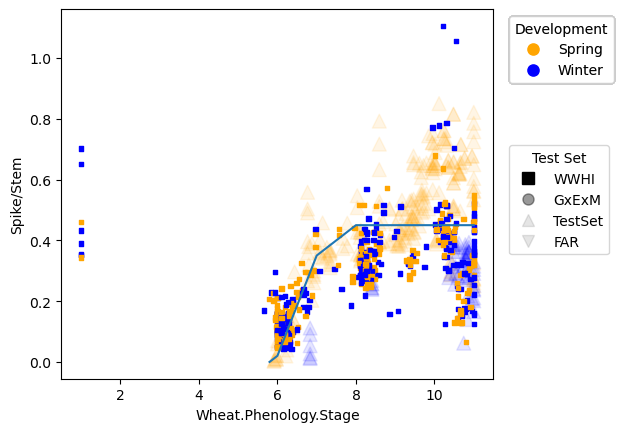

In [28]:
Observed.loc[:,'Spike/Stem'] = Observed.loc[:,'Wheat.Spike.Wt']/Observed.loc[:,'Wheat.Stem.Wt']
xvar,yvar = 'Wheat.Phenology.Stage','Spike/Stem'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed,cult_cols=True)
plt.plot([5.8,6.0,7.0,8.0,11.0],
         [0.0,.02,.35,.45,.45],'-')

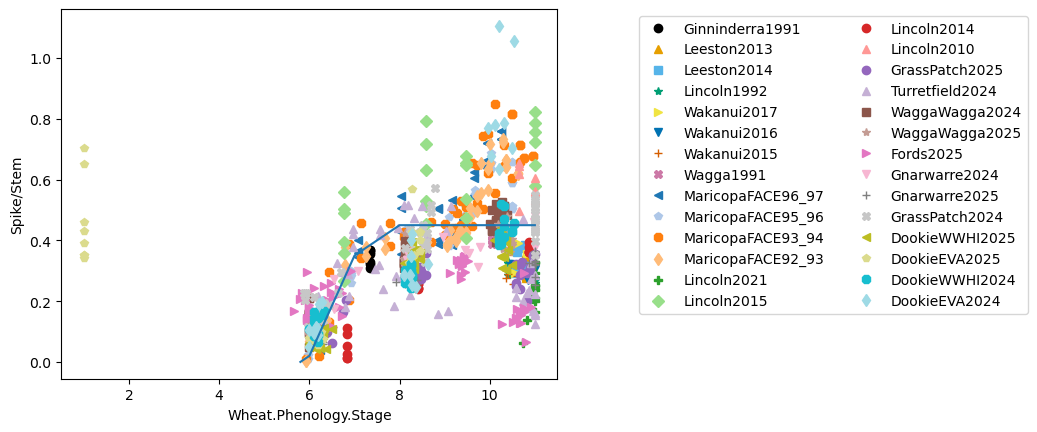

In [29]:
xvar,yvar = 'Wheat.Phenology.Stage','Spike/Stem'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
plt.plot([5.8,6.0,7.0,8.0,11.0],
         [0.0,.02,.35,.45,.45],'-')

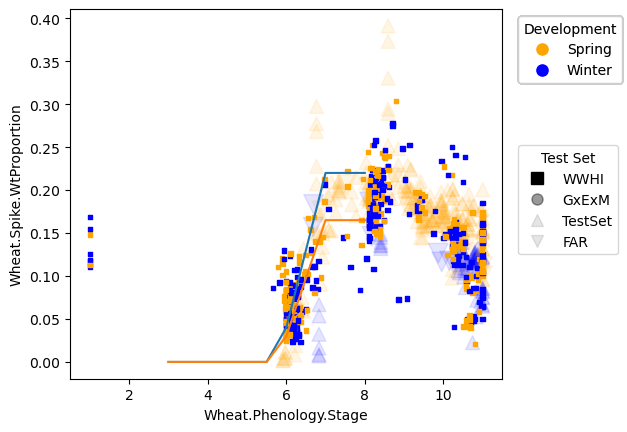

In [30]:
Observed.loc[:,'Wheat.Spike.WtProportion'] = Observed.loc[:,'Wheat.Spike.Wt']/Observed.loc[:,'Wheat.AboveGround.Wt']
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Spike.WtProportion'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed,cult_cols=True)
plt.plot([3.0,5.5, 6,7.0,8.0],
         [0,0,0.04,.22,.22],'-')
plt.plot([3.0,5.5, 6,7.0,8.0],
         np.multiply([0,0,0.04,.22,.22],0.75),'-')

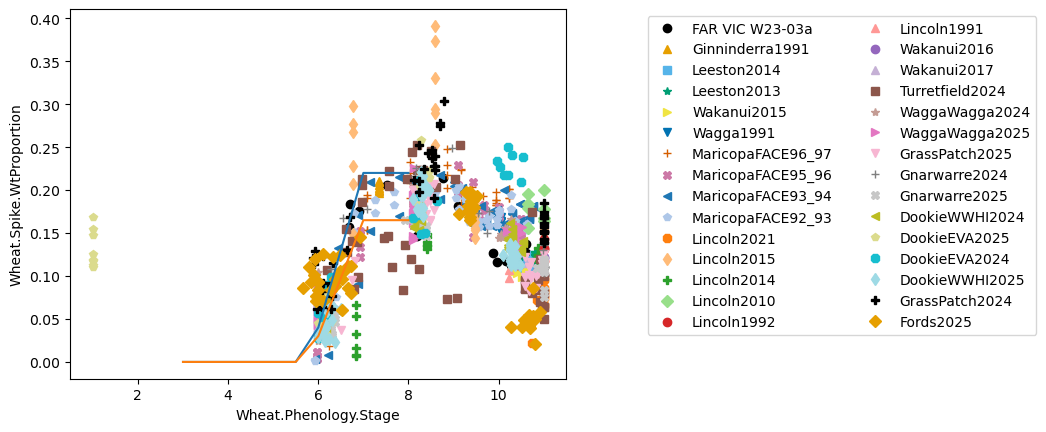

In [31]:
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Spike.WtProportion'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
plt.plot([3.0,5.5, 6,7.0,8.0],
         [0,0,0.04,.22,.22],'-')
plt.plot([3.0,5.5, 6,7.0,8.0],
         np.multiply([0,0,0.04,.22,.22],0.75),'-')

### Stem wt

KeyError: 'Pask TT07N0CvSavannah'

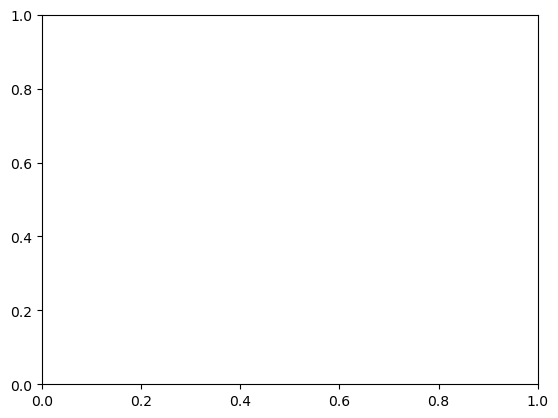

In [32]:
Observed.loc[:,'Wheat.Stem.WtProportion'] = Observed.loc[:,'Wheat.Stem.Wt']/Observed.loc[:,'Wheat.AboveGround.Wt']
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Stem.WtProportion'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed,cult_cols=True)
plt.plot([3.0,5.0, 6.0,8.0],
         [0.0,0.36,.65,.65],'-')
plt.plot([3.0,5.0, 6.0,8.0],
         np.multiply([0.0,0.36,.65,.65],0.7),'-')
plt.ylim(0,.9)

In [ ]:
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Stem.WtProportion'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
plt.plot([3.0,5.0, 6.0,8.0],
         [0.0,0.36,.65,.65],'-')
plt.plot([3.0,5.0, 6.0,8.0],
         np.multiply([0.0,0.36,.65,.65],0.7),'-')
plt.ylim(0,.9)

In [ ]:
xs = range(0,2500,10)
const = 1
power = 1
ys = [const * np.power(x,power) for x in xs]

In [ ]:
xvar,yvar = 'Wheat.AboveGround.Wt','Wheat.Stem.Wt'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed.loc[Observed.loc[:,"Wheat.Phenology.Stage"]<8.5,:],cult_cols=True)
xs = range(0,2500,10)
const = .135
power = 1.2
ys = [const * np.power(x,power) for x in xs]
plt.plot(xs,ys,'-')

In [ ]:
xvar,yvar = 'Wheat.AboveGround.Wt','Wheat.Stem.Wt'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed.loc[Observed.loc[:,"Wheat.Phenology.Stage"]<8.5,:])
xs = range(0,2500,10)
const = .135
power = 1.2
ys = [const * np.power(x,power) for x in xs]
plt.plot(xs,ys,'-')

### Leaf Wt

In [ ]:
Observed.loc[:,'Wheat.Leaf.LiveWtProportion'] = Observed.loc[:,'Wheat.Leaf.Live.Wt']/Observed.loc[:,'Wheat.AboveGroundLive.Wt']
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Leaf.LiveWtProportion'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed,cult_cols=True)
plt.plot([3.0,4.0,5.0,6.0,8.0],
         [1,.9,.7,.3,.15],'-')
plt.ylim(0,1)

In [ ]:
Observed.loc[:,'Wheat.Leaf.DeadWtProportion'] = Observed.loc[:,'Wheat.Leaf.Dead.Wt']/Observed.loc[:,'Wheat.AboveGround.Wt']
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Leaf.DeadWtProportion'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed,cult_cols=True)

In [ ]:
Observed.loc[:,'Wheat.Ear.WtProportion'] = Observed.loc[:,'Wheat.Ear.Wt']/Observed.loc[:,'Wheat.AboveGround.Wt']
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Ear.WtProportion'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed,cult_cols=True)
plt.plot([3.0,5.8,7.0,8.0,9.0,10,11],
         [0,0,.15,.2,.25,0.6,0.6],'-')

In [ ]:
xvar,yvar = 'Wheat.Phenology.AccumulatedTT','Wheat.Leaf.Dead.Wt'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed,cult_cols=True)

In [ ]:
xvar,yvar = 'Wheat.Phenology.AccumulatedTT','Wheat.Leaf.Live.Wt'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed,cult_cols=True)

In [ ]:
xvar,yvar = 'Wheat.Phenology.AccumulatedTT','Wheat.AboveGround.Wt'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed,cult_cols=True)

In [ ]:
xvar,yvar = 'Wheat.Phenology.AccumulatedTT','Wheat.Leaf.Live.Wt'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)

In [ ]:
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Leaf.Live.Wt'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed,cult_cols=True)

In [ ]:
experiments

In [ ]:
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Leaf.Live.Wt'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates().values
for e in experiments:
    cvs = Observed.loc[Observed.Experiment == e,'Wheat.SowingData.Cultivar'].drop_duplicates().values
    print(e)
    for c in cvs:
        print("  " + DevMap[c] + " " + c)

In [ ]:
Observed.loc[Observed.Experiment == e,'Wheat.SowingData.Cultivar'].drop_duplicates().values

# Specific Leaf Area

In [ ]:
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Leaf.SpecificAreaCanopy'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)

In [ ]:
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Leaf.SpecificAreaCanopy'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed,cult_cols=True)

In [ ]:
MetVars

In [ ]:
graph = plt.figure(figsize=(10,10))
ax = graph.add_subplot(3,2,1)
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Leaf.SpecificAreaCanopy'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed,ncols=2)
plt.text(0.05,0.95,'Wheat.Leaf.SpecificAreaCanopy',transform=ax.transAxes)
pos=3
for mv in MetVars:
    Observed.loc[:,'SLA * Normed '+mv] = pd.to_numeric(Observed.loc[:,'Wheat.Leaf.SpecificAreaCanopy'])*Observed.loc[:,'RunningMean_'+mv]
    testData = Observed.loc[Observed.loc[:,'Wheat.Phenology.Stage']<=6,:]
    ax = graph.add_subplot(3,2,pos)
    xvar,yvar = 'Wheat.Phenology.Stage','SLA * Normed '+mv
    experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
    plotxy(experiments,xvar,yvar,testData,addLeg=False)
    plt.text(0.05,0.95,'SLA * Normed '+mv,transform=ax.transAxes)
    pos+=1

In [ ]:
graph = plt.figure(figsize=(10,10))
ax = graph.add_subplot(3,2,1)
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Leaf.SpecificAreaCanopy'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed,ncols=2)
plt.text(0.05,0.95,'Wheat.Leaf.SpecificAreaCanopy',transform=ax.transAxes)
pos=3
for mv in MetVars:
    Observed.loc[:,'SLA * Normed '+mv] = pd.to_numeric(Observed.loc[:,'Wheat.Leaf.SpecificAreaCanopy'])*Observed.loc[:,'RunningMean_'+mv]
    testData = Observed.loc[Observed.loc[:,'Wheat.Phenology.Stage']<=10,:]
    ax = graph.add_subplot(3,2,pos)
    xvar,yvar = 'Wheat.Phenology.Stage','SLA * Normed '+mv
    experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
    plotxy(experiments,xvar,yvar,testData,addLeg=False)
    plt.text(0.05,0.95,'SLA * Normed '+mv,transform=ax.transAxes)
    pos+=1

In [ ]:
graph = plt.figure(figsize=(10,10))
ax = graph.add_subplot(3,2,1)
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Leaf.SpecificAreaCanopy'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
plt.text(0.05,0.95,'Wheat.Leaf.SpecificAreaCanopy',transform=ax.transAxes)
pos=3
for mv in MetVars:
    ax = graph.add_subplot(3,2,pos)
    xvar,yvar = 'Wheat.Phenology.Stage',mv
    experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
    plotxy(experiments,xvar,yvar,Observed,addLeg=False)
    plt.text(0.05,0.95,mv,transform=ax.transAxes)
    pos+=1

In [ ]:
graph = plt.figure(figsize=(10,10))
ax = graph.add_subplot(3,2,1)
xvar,yvar = 'Wheat.Leaf.LAI','Wheat.Leaf.SpecificAreaCanopy'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed,ncols=2)
plt.text(0.05,0.95,'Wheat.Leaf.SpecificAreaCanopy',transform=ax.transAxes)
pos=3
for mv in MetVars:
    testData = Observed.loc[Observed.loc[:,'Wheat.Phenology.Stage']<=6,:]
    ax = graph.add_subplot(3,2,pos)
    xvar,yvar = 'Wheat.Leaf.LAI','SLA * Normed '+mv
    experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
    plotxy(experiments,xvar,yvar,testData,addLeg=False)
    plt.text(0.05,0.95,'SLA * Normed '+mv,transform=ax.transAxes)
    pos+=1

In [ ]:
Observed.loc[:,'SLANormed'] = pd.to_numeric(Observed.loc[:,'Wheat.Leaf.SpecificAreaCanopy'])*Observed.loc[:,'RunningMean_IWeather.Radn']
xvar,yvar = 'Wheat.Phenology.Stage','SLANormed'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed,cult_cols=True)
plt.plot([3,4,6,11],[.1,.1,.4,.4],'-',color='k')

In [ ]:
SLAData = Observed.loc[:,['Wheat.Leaf.SpecificAreaCanopy','Wheat.Phenology.Stage','Experiment']].dropna().copy()
SLAExperiments = SLAData.Experiment.drop_duplicates()
SLAExpGraphs = plt.figure(figsize=(20,10))
pos=1
cpos=1
mpos=1
for e in SLAExperiments:
    ax = SLAExpGraphs.add_subplot(4,7,pos)
    ExpSLAData = SLAData.loc[SLAData.Experiment==e].droplevel(0)
    sims = ExpSLAData.index.get_level_values(0).drop_duplicates()
    for s in sims:
        y = pd.to_numeric(ExpSLAData.loc[s,'Wheat.Leaf.SpecificAreaCanopy'])
        x = pd.to_numeric(ExpSLAData.loc[s,'Wheat.Phenology.Stage'])
        scol = Colors[CondensedFactors.loc[(e,slice(None),s),'fIndex1'].values[0]]
        smar = Markers[CondensedFactors.loc[(e,slice(None),s),'fIndex2'].values[0]]
        plt.plot(x,y,smar,color=scol,label=s)
        cpos+=1
        mpos+=1
        if mpos>16:
            mpos=1
        if cpos>28:
            cpos=1
    plt.text(0.05,0.95,e,horizontalalignment='left',verticalalignment='center', transform=ax.transAxes)
    plt.ylim(0,0.04)
    plt.xlim(3,11)
    #plt.legend(fontsize=7)
    pos+=1    

# Stem number

In [ ]:
vars = ['Wheat.Leaf.StemNumberPerPlant','Wheat.Phenology.Stage']+['Experiment']
data = Observed.loc[:,vars].dropna()
experiments = data.Experiment.drop_duplicates()
cpos=1
mpos=1
for e in experiments:
    exData = data.loc[data.Experiment == e,:]
    plt.plot(exData.loc[:,'Wheat.Phenology.Stage'],exData.loc[:,'Wheat.Leaf.StemNumberPerPlant'],Markers[mpos],color=Colors[cpos],label=e)
    cpos+=1
    mpos+=1
    if mpos>16:
        mpos=1
    if cpos>28:
        cpos=1
plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=3)

In [ ]:
vars = ['Wheat.Leaf.StemNumberPerPlant','Wheat.Phenology.Stage']+['Experiment']
data = Observed.loc[:,vars].dropna()
experiments = data.Experiment.drop_duplicates()
cpos=1
mpos=1
for e in experiments:
    exData = data.loc[data.Experiment == e,:]
    sims = exData.index.get_level_values(0).drop_duplicates()
    spos = 0
    for s in sims:
        maxSN = exData.loc[s,'Wheat.Leaf.StemNumberPerPlant'].max()
        if spos == 0:
            plt.plot(exData.loc[s,'Wheat.Phenology.Stage'],exData.loc[s,'Wheat.Leaf.StemNumberPerPlant']/maxSN,Markers[mpos],color=Colors[cpos],label=e)
        else:
            plt.plot(exData.loc[s,'Wheat.Phenology.Stage'],exData.loc[s,'Wheat.Leaf.StemNumberPerPlant']/maxSN,Markers[mpos],color=Colors[cpos])
        spos+=1
    cpos+=1
    mpos+=1
    if mpos>16:
        mpos=1
    if cpos>28:
        cpos=1
plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=3)

In [ ]:
vars = ['Wheat.Leaf.StemPopulation','Wheat.Phenology.Stage']+['Experiment']
data = Observed.loc[:,vars].dropna()
experiments = data.Experiment.drop_duplicates()
cpos=1
mpos=1
for e in experiments:
    exData = data.loc[data.Experiment == e,:]
    sims = exData.index.get_level_values(0).drop_duplicates()
    spos = 0
    for s in sims:
        maxSN = exData.loc[s,'Wheat.Leaf.StemPopulation'].max()
        if spos == 0:
            plt.plot(exData.loc[s,'Wheat.Phenology.Stage'],exData.loc[s,'Wheat.Leaf.StemPopulation']/maxSN,Markers[mpos],color=Colors[cpos],label=e)
        else:
            plt.plot(exData.loc[s,'Wheat.Phenology.Stage'],exData.loc[s,'Wheat.Leaf.StemPopulation']/maxSN,Markers[mpos],color=Colors[cpos])
        spos+=1
    cpos+=1
    mpos+=1
    if mpos>16:
        mpos=1
    if cpos>28:
        cpos=1
plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=3)

In [ ]:
vars = ['Wheat.Leaf.StemPopulation','Wheat.Phenology.Stage']+['Experiment']
data = Observed.loc[:,vars].dropna()
experiments = data.Experiment.drop_duplicates()
cpos=1
mpos=1
for e in experiments:
    exData = data.loc[data.Experiment == e,:]
    plt.plot(exData.loc[:,'Wheat.Phenology.Stage'],exData.loc[:,'Wheat.Leaf.StemPopulation'],Markers[mpos],color=Colors[cpos],label=e)
    cpos+=1
    mpos+=1
    if mpos>16:
        mpos=1
    if cpos>28:
        cpos=1
plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=3)

In [ ]:
vars = ['Wheat.Leaf.StemPopulation','Wheat.Phenology.Stage','Wheat.Population','Wheat.Phenology.AccumulatedTT','Wheat.Leaf.StemNumberPerPlant']+['Experiment']
data = Observed.loc[:,vars].dropna(subset= ['Wheat.Leaf.StemPopulation','Wheat.Leaf.StemNumberPerPlant'],how='any')
experiments = data.Experiment.drop_duplicates()
cpos=1
mpos=1
pos=1
graph = plt.figure(figsize=(10,20))
for e in experiments:
    ax = graph.add_subplot(30,3,pos)
    exData = data.loc[data.Experiment == e,:]
    plt.plot(exData.loc[:,'Wheat.Phenology.Stage'],exData.loc[:,'Wheat.Leaf.StemNumberPerPlant'],Markers[mpos],color=Colors[cpos],label=e)
    plt.text(0.95,0.95,e,transform = ax.transAxes,horizontalalignment='right', verticalalignment='top')
    plt.xlim(0,12)
    cpos+=1
    mpos+=1
    pos+=1               
    if mpos>16:
        mpos=1
    if cpos>28:
        cpos=1
plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=3)

In [ ]:
vars = ['Wheat.Leaf.StemPopulation','Wheat.Phenology.Stage','Wheat.Population','Wheat.Phenology.AccumulatedTT','Wheat.Leaf.StemNumberPerPlant']+['Experiment']
data = Observed.loc[:,vars].dropna(subset= ['Wheat.Leaf.StemPopulation','Wheat.Leaf.StemNumberPerPlant'],how='any')
experiments = data.Experiment.drop_duplicates()
cpos=1
mpos=1
pos=1
graph = plt.figure(figsize=(10,20))
for e in experiments:
    ax = graph.add_subplot(30,3,pos)
    exData = data.loc[data.Experiment == e,:]
    plt.plot(exData.loc[:,'Wheat.Phenology.Stage'],exData.loc[:,'Wheat.Leaf.StemPopulation'],Markers[mpos],color=Colors[cpos],label=e)
    plt.text(0.95,0.95,e,transform = ax.transAxes,horizontalalignment='right', verticalalignment='top')
    plt.xlim(0,12)
    cpos+=1
    mpos+=1
    pos+=1               
    if mpos>16:
        mpos=1
    if cpos>28:
        cpos=1
plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=3)

In [ ]:
vars = ['Wheat.Leaf.StemPopulation','Wheat.Phenology.Stage','Wheat.Population','Wheat.Phenology.AccumulatedTT','Wheat.Leaf.StemNumberPerPlant']+['Experiment']
data = Observed.loc[:,vars].dropna(subset= ['Wheat.Leaf.StemPopulation','Wheat.Leaf.StemNumberPerPlant'],how='any')
experiments = data.Experiment.drop_duplicates()
cpos=1
mpos=1
pos=1
graph = plt.figure(figsize=(10,20))
for e in experiments:
    ax = graph.add_subplot(33,3,pos)
    exData = data.loc[data.Experiment == e,:]
    plt.plot(exData.loc[:,'Wheat.Phenology.Stage'],exData.loc[:,'Wheat.Population'],Markers[mpos],color=Colors[cpos],label=e)
    plt.text(0.95,0.95,e,transform = ax.transAxes,horizontalalignment='right', verticalalignment='top')
    plt.xlim(0,12)
    cpos+=1
    mpos+=1
    pos+=1               
    if mpos>16:
        mpos=1
    if cpos>28:
        cpos=1
plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=3)

In [ ]:
vars = ['Wheat.Leaf.StemPopulation','Wheat.Phenology.Stage','Wheat.Population','Wheat.Phenology.AccumulatedTT','Wheat.Leaf.StemNumberPerPlant']
data = Observed.loc[:,vars].dropna(subset= ['Wheat.Leaf.StemPopulation','Wheat.Leaf.StemNumberPerPlant'],how='any')
MeanStemData = data.loc[data.loc[:,'Wheat.Phenology.Stage']>7.5,:].groupby('SimulationName').mean()
MeanStemData.loc[:,'Experiment'] = [getValue(x,'Experiment',HarvestPred) for x in MeanStemData.index]

vars = ['Wheat.Stem.Wt','Wheat.Phenology.Stage']
data = Observed.loc[:,vars].dropna()
MeanStemWtData = data.loc[(data.loc[:,'Wheat.Phenology.Stage']>6.4)&(data.loc[:,'Wheat.Phenology.Stage']<9),:].groupby('SimulationName').mean()
MeanStemWtData.loc[:,'Experiment'] = [getValue(x,'Experiment',HarvestPred) for x in MeanStemWtData.index]
MeanStemData.loc[:,'Wheat.Stem.Wt'] = MeanStemWtData.reindex(MeanStemData.index).loc[:,'Wheat.Stem.Wt']
MeanStemData.loc[:,'MeanStemWt'] = MeanStemData.loc[:,'Wheat.Stem.Wt']/MeanStemData.loc[:,'Wheat.Leaf.StemPopulation']  

In [ ]:
experiments = MeanStemData.loc[:,'Experiment'].drop_duplicates()
xvar,yvar = 'Wheat.Population', 'Wheat.Leaf.StemNumberPerPlant'
plotxy(experiments,xvar,yvar,MeanStemData)
xs = range(40,300)
ys = [1000/(x+0) for x in xs]
plt.plot(xs,ys,'-',color='k',label='y=600/x')
plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=3)
plt.ylabel('Stems per plant (after anthesis)')
plt.xlabel('Wheat.population (plants/m2)')

In [ ]:
xvar,yvar = 'Wheat.Population', 'Wheat.Leaf.StemPopulation'
plotxy(experiments,xvar,yvar,MeanStemData)

xs = [0,300]
ys = [600,600]
plt.plot(xs,ys,'-',color='k',label='y=x')
plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=3)
plt.ylabel('Stems population (after anthesis)')
plt.xlabel('Wheat.population (plants/m2)')
plt.ylim(0,1000)

In [ ]:
experiments = list(MeanStemData.loc[:,'Experiment'].drop_duplicates())
cpos=1
mpos=1
for e in experiments:
    plotData = MeanStemData.loc[MeanStemData.Experiment==e,:]
    plt.plot(plotData.loc[:,'MeanStemWt'],plotData.loc[:,'Wheat.Leaf.StemNumberPerPlant'],Markers[mpos],color=Colors[cpos],label=e)
    cpos+=1
    mpos+=1
    if mpos>16:
        mpos=1
    if cpos>28:
        cpos=1
        
# xs = [0,300]
# ys = [600,600]
# plt.plot(xs,ys,'-',color='k',label='y=x')
plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=3)
plt.ylabel('Wheat.Leaf.StemNumberPerPlant')
plt.xlabel('Wheat.Stem.Wt')
#plt.ylim(0,1000)

In [ ]:
detailedStemData = ['APS2',
 'APS6',
 'Gatton2014',
 'Gatton2015',
 'Gatton2014Irrigated',
 'GattonRowSpacing',
 'Lincoln1992',
 'Lincoln2014',
 'Lincoln2023',
 'Lincoln2024',
 'MaricopaFACE92_93',
 'MaricopaFACE93_94',
 'MaricopaFACE95_96',
 'MaricopaFACE96_97']

In [ ]:
vars = ['Wheat.Leaf.StemPopulation','Wheat.Phenology.Stage','Wheat.Population','Wheat.Phenology.AccumulatedTT','Wheat.Leaf.StemNumberPerPlant']+['Experiment']
data = Observed.loc[:,vars].dropna(subset= ['Wheat.Leaf.StemPopulation','Wheat.Leaf.StemNumberPerPlant'],how='all')
pos=1
graph = plt.figure(figsize=(10,40))
for e in detailedStemData:
    ax = graph.add_subplot(15,3,pos)
    exData = data.loc[data.Experiment == e,:]
    sims = exData.index.get_level_values(1).drop_duplicates()
    spos = 0
    for s in sims:
        scol = Colors[CondensedFactors.loc[(e,slice(None),s),'fIndex1'].values[0]]
        smar = Markers[CondensedFactors.loc[(e,slice(None),s),'fIndex2'].values[0]]
        plt.plot(exData.loc[(slice(None),s),'Wheat.Phenology.Stage'],exData.loc[(slice(None),s),'Wheat.Leaf.StemNumberPerPlant'],smar,color=scol,label=e)
    plt.text(0.95,0.95,e,transform = ax.transAxes,horizontalalignment='right', verticalalignment='top')
    pos+=1
    plt.xlim(0,12)
    plt.ylim(0,20)

In [ ]:
vars = ['Wheat.Leaf.StemPopulation','Wheat.Phenology.Stage','Wheat.Population','Wheat.Phenology.AccumulatedTT','Wheat.Leaf.StemNumberPerPlant','Wheat.Leaf.CoverTotal']+['Experiment']
data = Observed.loc[:,vars].dropna(subset= ['Wheat.Leaf.StemPopulation','Wheat.Leaf.StemNumberPerPlant','Wheat.Leaf.CoverTotal'],how='all')
pos=1
graph = plt.figure(figsize=(10,40))
for e in detailedStemData:
    ax1 = graph.add_subplot(15,3,pos)
    exData = data.loc[data.Experiment == e,:]
    sims = exData.index.get_level_values(1).drop_duplicates()
    spos = 0
    for s in sims:
        scol = Colors[CondensedFactors.loc[(e,slice(None),s),'fIndex1'].values[0]]
        smar = Markers[CondensedFactors.loc[(e,slice(None),s),'fIndex2'].values[0]]
        plt.plot(exData.loc[(slice(None),s),'Wheat.Phenology.AccumulatedTT'],exData.loc[(slice(None),s),'Wheat.Phenology.Stage'],smar,color=scol,label=e)
        x = exData.loc[(slice(None),s),['Wheat.Phenology.Stage']].values.flatten()
        y = exData.loc[(slice(None),s),['Wheat.Phenology.AccumulatedTT']].values.flatten()
        vs = np.interp([4], x, y)[0]
        ts = np.interp([5], x, y)[0]
        plt.plot([vs,vs],[0,30],'--',color='orange')
        plt.plot([ts,ts],[0,30],'--',color='blue')
    plt.text(0.95,0.95,e,transform = ax1.transAxes,horizontalalignment='right', verticalalignment='top')
    plt.ylim(0,11)
    pos+=1

In [ ]:
vars = ['Wheat.Leaf.StemPopulation','Wheat.Phenology.Stage','Wheat.Population','Wheat.Phenology.AccumulatedTT','Wheat.Leaf.StemNumberPerPlant','Wheat.Leaf.CoverTotal']+['Experiment']
data = Observed.loc[:,vars].dropna(subset= ['Wheat.Leaf.StemPopulation','Wheat.Leaf.StemNumberPerPlant','Wheat.Leaf.CoverTotal'],how='all')
pos=1
graph = plt.figure(figsize=(10,40))
Phyllochron = 110
for e in detailedStemData:
    ax1 = graph.add_subplot(15,3,pos)
    exData = data.loc[data.Experiment == e,:]
    sims = exData.index.get_level_values(1).drop_duplicates()
    spos = 0
    for s in sims:
        scol = Colors[CondensedFactors.loc[(e,slice(None),s),'fIndex1'].values[0]]
        smar = Markers[CondensedFactors.loc[(e,slice(None),s),'fIndex2'].values[0]]
        plt.plot(exData.loc[(slice(None),s),'Wheat.Phenology.AccumulatedTT'],exData.loc[(slice(None),s),'Wheat.Leaf.StemNumberPerPlant'],smar,color=scol,label=e)
        x = exData.loc[(slice(None),s),['Wheat.Phenology.Stage']].values.flatten()
        y = exData.loc[(slice(None),s),['Wheat.Phenology.AccumulatedTT']].values.flatten()
        vs = np.interp([4], x, y)[0]
        ts = np.interp([5], x, y)[0]
        plt.plot([vs,vs],[0,30],'--',color='orange')
        plt.plot([ts,ts],[0,30],'--',color='blue')
    plt.plot(np.multiply([0,2.5,3.5,4.5,5.5,6.5],Phyllochron),[1,1,2,3,5,8],'-',color='k')    
    plt.text(0.95,0.95,e,transform = ax1.transAxes,horizontalalignment='right', verticalalignment='top')
    plt.ylim(0,20)
    pos+=1

In [ ]:
detailedStemAndCoverData = [
 'GattonRowSpacing',
 'Lincoln1992',
 'Lincoln2014',
 'Lincoln2023',
 'Lincoln2024']

In [ ]:
vars = ['Wheat.Leaf.StemPopulation','Wheat.Phenology.Stage','Wheat.Population','Wheat.Phenology.AccumulatedTT','Wheat.Leaf.StemNumberPerPlant','Wheat.Leaf.CoverTotal']+['Experiment']
data = Observed.loc[:,vars].dropna(subset= ['Wheat.Leaf.StemPopulation','Wheat.Leaf.StemNumberPerPlant','Wheat.Leaf.CoverTotal'],how='all')
pos=1
graph = plt.figure(figsize=(25,10))
for e in detailedStemAndCoverData:
    exData = data.loc[data.Experiment == e,:]
    sims = exData.index.get_level_values(1).drop_duplicates()
    for s in sims:
        ax1 = graph.add_subplot(6,7,pos)
        scol = Colors[CondensedFactors.loc[(e,slice(None),s),'fIndex1'].values[0]]
        smar = Markers[CondensedFactors.loc[(e,slice(None),s),'fIndex2'].values[0]]
        plt.plot(exData.loc[(slice(None),s),'Wheat.Phenology.Stage'],exData.loc[(slice(None),s),'Wheat.Leaf.StemNumberPerPlant'],smar,color=scol,label=e)
        plt.ylim(0,20)
        ax2 = ax1.twinx()
        plt.xlim(0,8)
        plt.ylim(0,1.1)
        col = Colors[CondensedFactors.loc[(e,slice(None),s),'fIndex1'].values[0]]
        plt.plot(exData.loc[(slice(None),s),'Wheat.Phenology.Stage'],exData.loc[(slice(None),s),'Wheat.Leaf.CoverTotal'],'-',color=col,label=e)
        plt.text(0.95,0.95,e,transform = ax2.transAxes,horizontalalignment='right', verticalalignment='top')
        pos+=1

In [ ]:
vars = ['Wheat.Leaf.StemPopulation','Wheat.Phenology.Stage','Wheat.Population','Wheat.Phenology.AccumulatedTT','Wheat.Leaf.StemNumberPerPlant']+['Experiment']
data = Observed.loc[:,vars].dropna(subset= ['Wheat.Leaf.StemPopulation','Wheat.Leaf.StemNumberPerPlant'],how='all')
pos=1
graph = plt.figure(figsize=(10,40))
for e in detailedStemData:
    ax = graph.add_subplot(15,3,pos)
    exData = data.loc[data.Experiment == e,:]
    sims = exData.index.get_level_values(1).drop_duplicates()
    spos = 0
    for s in sims:
        scol = Colors[CondensedFactors.loc[(e,slice(None),s),'fIndex1'].values[0]]
        smar = Markers[CondensedFactors.loc[(e,slice(None),s),'fIndex2'].values[0]]
        plt.plot(exData.loc[(slice(None),s),'Wheat.Phenology.Stage'],exData.loc[(slice(None),s),'Wheat.Leaf.StemPopulation'],smar,color=scol,label=e)
    plt.text(0.95,0.95,e,transform = ax.transAxes,horizontalalignment='right', verticalalignment='top')
    pos+=1
    plt.xlim(0,12)

In [ ]:
vars = ['Wheat.Stem.Wt','Wheat.Phenology.Stage']+['Experiment']
data = Observed.loc[:,vars].dropna(how='all')
pos=1
graph = plt.figure(figsize=(10,40))
for e in experiments:
    ax = graph.add_subplot(15,3,pos)
    exData = data.loc[data.Experiment == e,:]
    sims = exData.index.get_level_values(1).drop_duplicates()
    spos = 0
    for s in sims:
        scol = Colors[CondensedFactors.loc[(e,slice(None),s),'fIndex1'].values[0]]
        smar = Markers[CondensedFactors.loc[(e,slice(None),s),'fIndex2'].values[0]]
        plt.plot(exData.loc[(slice(None),s),'Wheat.Phenology.Stage'],exData.loc[(slice(None),s),'Wheat.Stem.Wt'],smar,color=scol,label=e)
    plt.text(0.95,0.95,e,transform = ax.transAxes,horizontalalignment='right', verticalalignment='top')
    pos+=1
    plt.xlim(0,12)

In [ ]:
vars = ['Wheat.Stem.Wt','Wheat.Phenology.Stage']
data = Observed.loc[:,vars].dropna()
MeanStemWtData = data.loc[(data.loc[:,'Wheat.Phenology.Stage']>6.4)&(data.loc[:,'Wheat.Phenology.Stage']<9),:].groupby('SimulationName').mean()
MeanStemWtData.loc[:,'Experiment'] = [getValue(x,'Experiment',HarvestPred) for x in MeanStemWtData.index]
MeanStemData.loc[:,'StemWt'] = MeanStemWtData.reindex(MeanStemData.index).loc[:,'Wheat.Stem.Wt']

# Organ Nitrogen Content

In [ ]:
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Leaf.Live.NConc'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
plt.plot([3.0,5.0,5.5,9.5,11.0],
         [0.055,.055,.045,.035,.005],'-')
plt.ylim(0,.08)

In [ ]:
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Leaf.Dead.NConc'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
plt.plot([3.0,4.5,5.5,9.5,11.0],
         [0.06,.06,.045,.035,.005],'-')
plt.ylim(0,.08)

In [ ]:
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Stem.NConc'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
plt.plot([3.0,4.5,6.0,9.5,11.0],
         [0.055,.055,.02,.012,.005],'-')
plt.ylim(0,.08)

In [ ]:
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Ear.NConc'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
plt.plot([6.0,11.0],
         [0.02,.02],'-')
plt.ylim(0,.08)

In [ ]:
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Spike.NConc'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
plt.plot([6.0,8.5,10.2],
         [0.024,.024,.005],'-')
plt.ylim(0,.03)

In [ ]:
xvar,yvar = 'Wheat.Spike.NConc','Wheat.Grain.NConc'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
# plt.plot([3.0,4.5,5.5,9.5,11.0],
#          [0.06,.06,.045,.035,.005],'-')
#plt.ylim(0,.08)

In [ ]:
Observed.loc[:,'Wheat.AboveGround.NConc'] = pd.to_numeric(Observed.loc[:,'Wheat.AboveGround.N'])/pd.to_numeric(Observed.loc[:,'Wheat.AboveGround.Wt'])
xvar,yvar = 'Wheat.AboveGround.Wt','Wheat.AboveGround.NConc'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)
def funct(b1,b2,b3,x):
    return b1 + np.exp(b2+(b3*x))
xs = range(0,3000,10)
ys = [funct(0.81,1.68,-0.00152,x)/100 for x in xs]                       
plt.plot(xs,ys,'-')
ys = [funct(0.35,1.55,-0.00738,x)/100 for x in xs]                       
plt.plot(xs,ys,'-')

# Grain wt and number

In [ ]:
xvar,yvar = 'Wheat.Grain.Size','Wheat.Grain.NConc'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed)

In [ ]:
def plotxySizeScaled(experiments,xvar,yvar,data,sizeVar,sizeScaler,addLeg = True,ncols=np.nan):
    cpos=1
    mpos=1
    for e in experiments:
        plotData = data.loc[data.Experiment==e,:]
        xdata = pd.to_numeric(plotData.loc[:,xvar])
        ydata = pd.to_numeric(plotData.loc[:,yvar])
        sizeVal = pd.to_numeric(plotData.loc[:,sizeVar])/sizeScaler
        for s in xdata.index:
            label = e if s == xdata.index[0] else None
            plt.plot(xdata[s],ydata[s],Markers[mpos],color=Colors[cpos], ms=sizeVal[s],label=label)
        cpos+=1
        mpos+=1
        if mpos>16:
            mpos=1
        if cpos>28:
            cpos=1
    if addLeg == True:
        if np.isnan(ncols):
             ncols = np.ceil(experiments.size/17)
        plt.legend(bbox_to_anchor=(1.15, 1),numpoints=1,ncols=ncols)
    plt.ylabel(yvar)
    plt.xlabel(xvar)

In [ ]:
def Value_at_stage(df, variable, target, tol_low, tol_high):

    # Filter stage window
    window = df.loc[
        (df["Wheat.Phenology.Stage"] > tol_low) &
        (df["Wheat.Phenology.Stage"] < tol_high)
    ].copy()

    window = window[window[variable].notna()]

    if window.empty:
        return pd.DataFrame(columns=[variable])

    # Distance to target stage
    window["stage_dist"] = (window["Wheat.Phenology.Stage"] - target).abs()

    # Choose closest per simulation
    out = (
        window
        .sort_values("stage_dist")
        .loc[~window.index.droplevel(-1).duplicated()]
        .loc[:, [variable, "Experiment"]]
        .droplevel(-1)  # drop Clock.Today
    )

    return out

In [ ]:
Observed.loc[:,'Wheat.Phenology.PTQ']

In [ ]:
AnthesisStemWt = Value_at_stage(Observed, 'Wheat.Stem.Wt', 8, 6.5, 8.5)
AnthesisStemWt.loc[:,'Wheat.Grain.Number'] = np.nan
for sim in AnthesisStemWt.index:
    AnthesisStemWt.loc[sim,'Wheat.Grain.Number'] = np.mean(Observed.loc[sim[0:2],'Wheat.Grain.Number'].dropna().values)
    AnthesisStemWt.loc[sim,'Wheat.Grain.Wt'] = np.mean(Observed.loc[sim[0:2],'Wheat.Grain.Wt'].dropna().values)
AnthesisStemWt.loc[:,'Wheat.StemPlusSpikeWt'] = AnthesisStemWt.loc[:,'Wheat.Stem.Wt'] * 1.4 #  Based on analysis above, spike wt = 0.4 * stem wt at anthesis
AnthesisStemWt.loc[:,'Wheat.GrainPerGramOfStemPlusSpike'] =  AnthesisStemWt.loc[:,'Wheat.Grain.Number']/AnthesisStemWt.loc[:,'Wheat.StemPlusSpikeWt']
AnthesisStemWt = AnthesisStemWt.groupby(level=[0, 1]).first()
#Add PTQ mean into data table
MetVar = 'Wheat.Phenology.PTQ'
for sim in AnthesisStemWt.index:
    try:
        metData = RunningMeans.loc[sim[0:2],[MetVar,'Wheat.Phenology.Stage']]
        stageFilter = (metData.loc[:,'Wheat.Phenology.Stage'] >= 6) & (metData.loc[:,'Wheat.Phenology.Stage'] <= 8)
        metVarMean = metData.loc[stageFilter,MetVar].mean()
        AnthesisStemWt.loc[sim,MetVar+"Critical"] = metVarMean
    except:
        do = 'nothing'
for sim in AnthesisStemWt.index:
    #try:
    metData = Observed.loc[sim[0:2],[MetVar,'Wheat.Phenology.Stage']]
    stageFilter = (metData.loc[:,'Wheat.Phenology.Stage'] >= 6) & (metData.loc[:,'Wheat.Phenology.Stage'] <= 8)
    metVarMean = metData.loc[stageFilter,MetVar].mean()
    AnthesisStemWt.loc[sim,MetVar+"CriticalMean"] = metVarMean
    # except:
    #     do = 'nothing'
AnthesisStemWt.loc[:,'Stem/PTQ'] = AnthesisStemWt.loc[:,'Wheat.StemPlusSpikeWt']/AnthesisStemWt.loc[:,'Wheat.Phenology.PTQCritical']
AnthesisStemWt.loc[:,'PotGNStemWt'] = AnthesisStemWt.loc[:,'Wheat.StemPlusSpikeWt'] * 24
AnthesisStemWt.loc[:,'PotGNPTQ'] = -16153 + AnthesisStemWt.loc[:,'Wheat.Phenology.PTQCritical'] * 13461
AnthesisStemWt.loc[:,'PotGN'] = np.minimum(AnthesisStemWt.loc[:,'PotGNStemWt'],AnthesisStemWt.loc[:,'PotGNPTQ'])

In [ ]:
AnthesisStemWt

In [ ]:
experiments = AnthesisStemWt.Experiment.drop_duplicates()
plotxySizeScaled(experiments,'Wheat.StemPlusSpikeWt','Wheat.Grain.Number',AnthesisStemWt,'Wheat.Grain.Wt',150,ncols=3)
xs=[0,1600]
# plt.plot(xs,np.multiply(xs,40),'-')
plt.plot(xs,np.multiply(xs,26),'-')
# plt.plot(xs,np.multiply(xs,14),'-')
xs = range(0,2200,10)
def mm(GNmax, x, k):
    return (GNmax * x)/(k+x)
def pow(alp, x, pow):
    return alp*np.power(x,pow)

#plt.plot(xs,[mm(60000,x,1000) for x in xs],'-')
plt.plot(xs,[pow(150,x,0.7) for x in xs],'-')
plt.plot([0,700],[0,40000],'-')

In [ ]:
b = 35000/(3.8-1.2)
a = 1.2 * -b

In [ ]:
b

In [ ]:
a

In [ ]:
experiments = AnthesisStemWt.Experiment.drop_duplicates()
plotxySizeScaled(experiments,'Wheat.Phenology.PTQCriticalMean','Wheat.Grain.Number',AnthesisStemWt,'Wheat.Grain.Wt',150,ncols=3)
plt.plot([1.2,3.8],[0,35000],'-')
xs=[0,1600]
# plt.plot(xs,np.multiply(xs,40),'-')
#plt.plot(xs,np.multiply(xs,26),'-')
# plt.plot(xs,np.multiply(xs,14),'-')
xs = range(0,2200,10)
def mm(GNmax, x, k):
    return (GNmax * x)/(k+x)
def pow(alp, x, pow):
    return alp*np.power(x,pow)

#plt.plot(xs,[mm(60000,x,1000) for x in xs],'-')
#plt.plot(xs,[pow(100,x,0.7) for x in xs],'-')

In [ ]:
experiments = AnthesisStemWt.Experiment.drop_duplicates()
plotxySizeScaled(experiments,'PotGN','Wheat.Grain.Number',AnthesisStemWt,'Wheat.Grain.Wt',150,ncols=3)
plt.plot([0,40000],[0,40000],'-')
xs=[0,1600]
# plt.plot(xs,np.multiply(xs,40),'-')
#plt.plot(xs,np.multiply(xs,26),'-')
# plt.plot(xs,np.multiply(xs,14),'-')
xs = range(0,2200,10)
def mm(GNmax, x, k):
    return (GNmax * x)/(k+x)
def pow(alp, x, pow):
    return alp*np.power(x,pow)

#plt.plot(xs,[mm(60000,x,1000) for x in xs],'-')
#plt.plot(xs,[pow(100,x,0.7) for x in xs],'-')

In [ ]:
experiments = AnthesisStemWt.Experiment.drop_duplicates()
plotxySizeScaled(experiments,'Wheat.Stem.Wt','Wheat.GrainPerGramOfStemPlusSpike',AnthesisStemWt,'Wheat.Grain.Wt',150,ncols=3)
xs = range(100,1600,10)
def expon(x, a, b, c):
    return a + b * np.exp(c*x)
plt.plot(xs,[expon(x,13,30,-.002) for x in xs],'-')

In [ ]:
AnthesisLeafWt = Value_at_stage(Observed, 'Wheat.Leaf.Live.Wt', 8, 6.5, 8.5)
AnthesisLeafWt.loc[:,'Wheat.Grain.Number'] = np.nan
for sim in AnthesisLeafWt.index:
    AnthesisLeafWt.loc[sim,'Wheat.Grain.Number'] = np.mean(Observed.loc[sim[0:2],'Wheat.Grain.Number'].dropna().values)
    AnthesisLeafWt.loc[sim,'Wheat.Grain.Wt'] = np.mean(Observed.loc[sim[0:2],'Wheat.Grain.Wt'].dropna().values)

In [ ]:
experiments = AnthesisLeafWt.Experiment.drop_duplicates()
plotxySizeScaled(experiments,'Wheat.Leaf.Live.Wt','Wheat.Grain.Number',AnthesisLeafWt,'Wheat.Grain.Wt',150,ncols=3)
xs=[0,500]
plt.plot(xs,np.multiply(xs,130),'-')
plt.plot(xs,np.multiply(xs,100),'-')
plt.plot(xs,np.multiply(xs,70),'-')

In [ ]:
AnthesisTotalWt = Value_at_stage(Observed, 'Wheat.AboveGround.Wt', 8, 6.5, 8.5)
AnthesisTotalWt.loc[:,'Wheat.Grain.Number'] = np.nan
for sim in AnthesisTotalWt.index:
    AnthesisTotalWt.loc[sim,'Wheat.Grain.Number'] = np.mean(Observed.loc[sim[0:2],'Wheat.Grain.Number'].dropna().values)
    AnthesisTotalWt.loc[sim,'Wheat.Grain.Wt'] = np.mean(Observed.loc[sim[0:2],'Wheat.Grain.Wt'].dropna().values)

In [ ]:
experiments = AnthesisTotalWt.Experiment.drop_duplicates()
plotxySizeScaled(experiments,'Wheat.AboveGround.Wt','Wheat.Grain.Number',AnthesisTotalWt,'Wheat.Grain.Wt',150,ncols=3)
xs=[0,2500]
plt.plot(xs,np.multiply(xs,25),'-')
plt.plot(xs,np.multiply(xs,15),'-')
plt.plot(xs,np.multiply(xs,10),'-')

In [ ]:
AnthesisSpikeWt = Value_at_stage(Observed, 'Wheat.Spike.Wt', 8, 6.5, 8.5)
AnthesisSpikeWt.loc[:,'Wheat.Grain.Number'] = np.nan
for sim in AnthesisSpikeWt.index:
    AnthesisSpikeWt.loc[sim,'Wheat.Grain.Number'] = np.mean(Observed.loc[sim[0:2],'Wheat.Grain.Number'].dropna().values)
    AnthesisSpikeWt.loc[sim,'Wheat.Grain.Wt'] = np.mean(Observed.loc[sim[0:2],'Wheat.Grain.Wt'].dropna().values)

In [ ]:
experiments = AnthesisSpikeWt.Experiment.drop_duplicates()
plotxySizeScaled(experiments,'Wheat.Spike.Wt','Wheat.Grain.Number',AnthesisSpikeWt,'Wheat.Grain.Wt',150,ncols=3)
xs=[0,300]
plt.plot(xs,np.multiply(xs,90),'-')
plt.plot(xs,np.multiply(xs,60),'-')
plt.plot(xs,np.multiply(xs,30),'-')

In [ ]:
gwts = range(100,1800,300)
gns = range(1000,41000,1000)
for gwt in gwts:
    gss = []
    for gn in gns:
        maxGS = 0.06 - 0.00000055*gn
        y = min(maxGS,gwt/gn)
        gss.append(y)
    plt.plot(gns,gss,"-",color='grey')
xvar,yvar = 'Wheat.Grain.Number','Wheat.Grain.Size'
harvFilter = Observed.loc[:,'Wheat.Phenology.CurrentStageName'] == "HarvestRipe"
experiments = Observed.loc[harvFilter,:].dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxySizeScaled(experiments,xvar,yvar,Observed.loc[harvFilter,:],'Wheat.Grain.Wt',150,ncols=3)
#plt.plot([500,16000,40000],[0.052,0.052,0.04],"-")

plt.ylim(0,0.06)

In [ ]:
Observed.loc[:,'Wheat.Stem.WtPerGrain'] = Observed.loc[:,'Wheat.Stem.Wt']/Observed.loc[:,'Wheat.Grain.Number']
xvar,yvar = 'Wheat.Stem.WtPerGrain','Wheat.Grain.Size'
harvFilter = Observed.loc[:,'Wheat.Phenology.CurrentStageName'] == "HarvestRipe"
experiments = Observed.loc[harvFilter,:].dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed.loc[harvFilter,:])
#plt.plot([500,16000,40000],[0.052,0.052,0.04],"-")

In [ ]:
Observed.loc[:,'Wheat.Spike.WtPerGrain'] = Observed.loc[:,'Wheat.Spike.Wt']/Observed.loc[:,'Wheat.Grain.Number']
xvar,yvar = 'Wheat.Spike.WtPerGrain','Wheat.Grain.Size'
harvFilter = Observed.loc[:,'Wheat.Phenology.CurrentStageName'] == "HarvestRipe"
experiments = Observed.loc[harvFilter,:].dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
plotxy(experiments,xvar,yvar,Observed.loc[harvFilter,:])
#plt.plot([500,16000,40000],[0.052,0.052,0.04],"-")

In [ ]:
harvFilter = Observed.loc[:,'Wheat.Phenology.CurrentStageName'] == "HarvestRipe"
HarvVar = 'Wheat.Grain.Number'
MetVar = 'Wheat.Phenology.PTQ'
startStage = 6
endStage = 8
HarvestData = pd.DataFrame(Observed.loc[harvFilter,[HarvVar,'Wheat.Grain.Wt','Experiment']].dropna())
for sim in HarvestData.index:
    try:
        metData = RunningMeans.loc[sim[0:2],[MetVar,'Wheat.Phenology.Stage']]
        stageFilter = (metData.loc[:,'Wheat.Phenology.Stage'] >= 6) & (metData.loc[:,'Wheat.Phenology.Stage'] <= 8)
        metVarMean = metData.loc[stageFilter,MetVar].mean()
        #simYield = HarvestData.loc[sim,'Wheat.Grain.Wt']
        #harVarValue = HarvestData.loc[sim,HarvVar]
        HarvestData.loc[sim,MetVar+"Cricital"] = metVarMean,
        #plt.plot(metVarMean, harVarValue,'o',ms = simYield/200)
    except:
        do = 'nothing'
#plt.plot(HarvestData.loc[:,MetVar],HarvestData.loc[:,HarvVar],'o')
experiments = HarvestData.dropna(subset=[MetVar+"Cricital",HarvVar]).Experiment.drop_duplicates()
plotxySizeScaled(experiments,MetVar+"Cricital",HarvVar,HarvestData,'Wheat.Grain.Wt',150,ncols=3)
plt.plot([1.2,3.8],[0,40000],'-')

In [ ]:
MetVar = 'Wheat.Phenology.PTQ'
for sim in AnthesisStemWt.index:
    try:
        metData = RunningMeans.loc[sim[0:2],[MetVar,'Wheat.Phenology.Stage']]
        stageFilter = (metData.loc[:,'Wheat.Phenology.Stage'] >= 6) & (metData.loc[:,'Wheat.Phenology.Stage'] <= 8)
        metVarMean = metData.loc[stageFilter,MetVar].mean()
        #simYield = HarvestData.loc[sim,'Wheat.Grain.Wt']
        #harVarValue = HarvestData.loc[sim,HarvVar]
        AnthesisStemWt.loc[sim,MetVar+"Cricital"] = metVarMean,
        #plt.plot(metVarMean, harVarValue,'o',ms = simYield/200)
    except:
        do = 'nothing'

In [ ]:
AnthesisStemWt

In [ ]:
experiments = AnthesisStemWt.Experiment.drop_duplicates()
plotxySizeScaled(experiments,'Wheat.StemPlusSpikeWt','Wheat.Grain.Number',AnthesisStemWt,'Wheat.Grain.Wt',150,ncols=3)
xs=[0,1600]
# plt.plot(xs,np.multiply(xs,40),'-')
plt.plot(xs,np.multiply(xs,26),'-')
# plt.plot(xs,np.multiply(xs,14),'-')
xs = range(0,2200,10)
def mm(GNmax, x, k):
    return (GNmax * x)/(k+x)
def pow(alp, x, pow):
    return alp*np.power(x,pow)

#plt.plot(xs,[mm(60000,x,1000) for x in xs],'-')
plt.plot(xs,[pow(150,x,0.7) for x in xs],'-')

In [ ]:
harvFilter = Observed.loc[:,'Wheat.Phenology.CurrentStageName'] == "HarvestRipe"
HarvVar = 'Wheat.Grain.Size'
MetVar = 'IWeather.Radn'#'Wheat.Phenology.PTQ'
startStage = 4
endStage = 9
HarvestData = pd.DataFrame(Observed.loc[harvFilter,[HarvVar,'Wheat.Grain.Wt']].dropna())
for sim in HarvestData.index:
    try:
        metData = RunningMeans.loc[sim[0:2],[MetVar,'Wheat.Phenology.Stage']]
        stageFilter = (metData.loc[:,'Wheat.Phenology.Stage'] >= 6) & (metData.loc[:,'Wheat.Phenology.Stage'] <= 8)
        metVarMean = metData.loc[stageFilter,MetVar].mean()
        simYield = HarvestData.loc[sim,'Wheat.Grain.Wt']
        harVarValue = HarvestData.loc[sim,HarvVar]
        #HarvestData.loc[sim,MetVar] = VarMean,
        plt.plot(metVarMean, harVarValue,'o',ms = simYield/200)
    except:
        do = 'nothing'
#plt.plot(HarvestData.loc[:,MetVar],HarvestData.loc[:,HarvVar],'o')
#plt.plot([1.2,4],[0,40000],'-')

In [ ]:
gwts = range(100,1800,300)
gns = range(1000,41000,1000)
for gwt in gwts:
    gss = []
    for gn in gns:
        maxGS = 0.06 - 0.00000055*gn
        y = min(maxGS,gwt/gn)
        gss.append(y)
    plt.plot(gns,gss,"-")
harvFilter = Observed.loc[:,'Wheat.Phenology.CurrentStageName'] == "HarvestRipe"
HarvVar = 'Wheat.Grain.Size'
MetVar = 'IWeather.Radn'#'Wheat.Phenology.PTQ'
startStage = 4
endStage = 9
HarvestData = pd.DataFrame(Observed.loc[harvFilter,['Wheat.Grain.Number','Wheat.Grain.Size','Wheat.Grain.Wt']].dropna())
for sim in HarvestData.index:
    try:
        metData = RunningMeans.loc[sim[0:2],[MetVar,'Wheat.Phenology.Stage']]
        stageFilter = (metData.loc[:,'Wheat.Phenology.Stage'] >= 6) & (metData.loc[:,'Wheat.Phenology.Stage'] <= 8)
        y = HarvestData.loc[sim,'Wheat.Grain.Size']
        simYield = HarvestData.loc[sim,'Wheat.Grain.Wt']
        x = HarvestData.loc[sim,'Wheat.Grain.Number']
        #HarvestData.loc[sim,MetVar] = VarMean,
        plt.plot(x, y,'o',ms = simYield/150)
    except:
        do = 'nothing'
#plt.plot(HarvestData.loc[:,MetVar],HarvestData.loc[:,HarvVar],'o')
#plt.plot([1.2,4],[0,40000],'-')

In [ ]:
GrainNData = Observed.loc[:,['Wheat.Grain.Wt','Wheat.Grain.NConc','Wheat.Grain.N','Wheat.Phenology.Stage','Experiment']].dropna().copy()
GrainNexperiments = GrainNData.Experiment.drop_duplicates()
GrainNExpGraphs = plt.figure(figsize=(20,10))
pos=1
for e in GrainNexperiments:
    ax = GrainNExpGraphs.add_subplot(4,6,pos)
    ExpGrainNData = GrainNData.loc[GrainNData.Experiment==e].droplevel(0)
    sims = ExpGrainNData.index.get_level_values(0).drop_duplicates()
    for s in sims:
        y = pd.to_numeric(ExpGrainNData.loc[s,'Wheat.Grain.NConc'])
        x = pd.to_numeric(ExpGrainNData.loc[s,'Wheat.Phenology.Stage'])
        scol = Colors[CondensedFactors.loc[(e,slice(None),s),'fIndex1'].values[0]]
        smar = Markers[CondensedFactors.loc[(e,slice(None),s),'fIndex2'].values[0]]
        plt.plot(x,y,smar,color=scol,label=s)
        cpos+=1
        mpos+=1
        if mpos>16:
            mpos=1
        if cpos>28:
            cpos=1
    plt.text(0.05,0.95,e,horizontalalignment='left',verticalalignment='center', transform=ax.transAxes)
    plt.ylim(0,0.04)
    plt.xlim(3,11)
    #plt.legend(fontsize=7)
    pos+=1    

# Extinction Coefficient

In [ ]:
kgraph = plt.figure(figsize=(10,5))
cpos = 1
mpos = 1
expts = Observed.index.get_level_values(0).drop_duplicates()
for e in experiments:
    expData = Observed.loc[Observed.Experiment==e,:].droplevel(0)
    sims = expData.index.get_level_values(0).drop_duplicates()
    expDF = pd.DataFrame()
    for s in sims:
        left = expData.loc[s, ['Wheat.Leaf.CoverTotal']].dropna().copy()
        right = expData.loc[s, ['Wheat.Leaf.LAI','Wheat.Phenology.Stage']].dropna().copy()
        left.index = pd.to_datetime(left.index)
        right.index = pd.to_datetime(right.index)
        if ((left.index.size>0) and (right.index.size>0)):
            left = left.sort_index()
            right = right.sort_index()
            df = pd.merge_asof(
                left, right,
                left_index=True,
                right_index=True,
                direction="nearest",
                tolerance=pd.Timedelta("3D")
            )
            df["K"] = -np.log(1.0 - df["Wheat.Leaf.CoverTotal"]) / df["Wheat.Leaf.LAI"]  
            expDF = pd.concat([expDF,df])
            #df = df.loc[df['Wheat.Leaf.CoverTotal']>.2,:]
    if (expDF.index.size>0):
        plt.plot(expDF.loc[:,'Wheat.Phenology.Stage'],expDF.loc[:,'K'],Markers[mpos],color=Colors[cpos],label=e)
        cpos+=1
        mpos+=1
        if mpos>16:
            mpos=1
        if cpos>28:
            cpos=1
plt.ylim(0,1.1)
plt.xlim(3,7)
plt.legend(bbox_to_anchor=(.5, .7),numpoints=1,ncols=2)
plt.ylabel('K')
plt.xlabel('Wheat.Phenology.Stage')
plt.plot([4,4.8,5.2,6],[0.75,0.75,0.55,0.55],'-')

In [ ]:
SLAData = Observed.loc[:,['Wheat.Leaf.SpecificAreaCanopy','Wheat.Phenology.Stage','Experiment']].dropna().copy()
SLAexperiments = SLAData.Experiment.drop_duplicates()
SLAExpGraphs = plt.figure(figsize=(20,10))
pos=1
for e in SLAexperiments:
    ax = SLAExpGraphs.add_subplot(4,6,pos)
    ExpSLAData = SLAData.loc[SLAData.Experiment==e].droplevel(0)
    sims = ExpSLAData.index.get_level_values(0).drop_duplicates()
    for s in sims:
        y = pd.to_numeric(ExpSLAData.loc[s,'Wheat.Leaf.SpecificAreaCanopy'])
        x = pd.to_numeric(ExpSLAData.loc[s,'Wheat.Phenology.Stage'])
        scol = Colors[CondensedFactors.loc[(e,slice(None),s),'fIndex1'].values[0]]
        smar = Markers[CondensedFactors.loc[(e,slice(None),s),'fIndex2'].values[0]]
        plt.plot(x,y,smar,color=scol,label=s)
        cpos+=1
        mpos+=1
        if mpos>16:
            mpos=1
        if cpos>28:
            cpos=1
    plt.text(0.05,0.95,e,horizontalalignment='left',verticalalignment='center', transform=ax.transAxes)
    plt.ylim(0,0.04)
    plt.xlim(3,11)
    #plt.legend(fontsize=7)
    pos+=1    

# Above Ground N

In [ ]:
AGNexperiments = ['APS2',
 'APS26',
 'APS6',
 'FAR NSW W23-05',
 'FAR RRC W22-05-1',
 'Ginninderra1991',
 'Lincoln1991',
 'Lincoln1992',
 'Lincoln2015',
 'Lincoln2024',
 'MaricopaFACE96_97',
 'Pask LC07',
 'Pask TT06',
 'Pask TT07',
 'Wagga1991']

Observed.loc[:,'Wheat.AboveGround.N'] = pd.to_numeric(Observed.loc[:,'Wheat.AboveGround.N'] )
AGNData = Observed.loc[:,['Wheat.AboveGround.N','Wheat.Phenology.Stage','Experiment']].dropna().copy()
#AGNexperiments = AGNData.Experiment.drop_duplicates()
AGNGraphs = plt.figure(figsize=(10,20))
pos=1
Nexpts = []
for e in AGNexperiments:
    ax = AGNGraphs.add_subplot(8,3,pos)
    ExpAGNData = AGNData.loc[AGNData.Experiment==e].droplevel(0)
    ExpAGNData.drop_duplicates(inplace=True)
    sims = ExpAGNData.index.get_level_values(0).drop_duplicates()
    for s in sims:
        if ExpAGNData.loc[s,'Wheat.AboveGround.N'].count() > 2:
            Nexpts.append(e)
        simMaxAGN = ExpAGNData.loc[s,'Wheat.AboveGround.N'].max()
        ExpAGNData.loc[s,'RelativeNUptake'] = (ExpAGNData.loc[s,'Wheat.AboveGround.N']/simMaxAGN).values
        y = ExpAGNData.loc[s,'RelativeNUptake']
        x = ExpAGNData.loc[s,'Wheat.Phenology.Stage']
        scol = Colors[CondensedFactors.loc[(e,slice(None),s),'fIndex1'].values[0]]
        smar = Markers[CondensedFactors.loc[(e,slice(None),s),'fIndex2'].values[0]]
        plt.plot(x,y,smar+'--',color=scol,label=s)
        cpos+=1
        mpos+=1
        if mpos>16:
            mpos=1
        if cpos>28:
            cpos=1
    plt.plot([8,8],[0,1.5],'--',color='orange')
    plt.text(0.05,0.95,e,horizontalalignment='left',verticalalignment='center', transform=ax.transAxes)
    plt.ylim(0,1.05)
    plt.xlim(3,12)
    if pos in [1,4,7,10,13]:
        plt.ylabel('Relative AboveGround.N')
    if pos in [13,14,15]:
        plt.xlabel('Wheat.Phenology.Stage')
    #plt.legend(fontsize=7)
    pos+=1   
AGNGraphs.savefig('RelativeNUptake.png')

In [ ]:
simulations = list(Observed.index.get_level_values(1).drop_duplicates())

In [ ]:
for sim in simulations:
    try:
        plt.plot(max(Observed.loc[(slice(None),sim),"Wheat.AboveGround.Wt"].dropna().values),
             max(Observed.loc[(slice(None),sim),"Wheat.Stem.WtProportion"].dropna().values),'o')
    except:
        do='Nothing'

In [ ]:
Observed.loc[:,"Wheat.Phenology.Stage"] > 5.5 

In [ ]:
list(Observed["Wheat.SowingData.Cultivar"].drop_duplicates().values)

In [ ]:
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Leaf.LiveWtProportion'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()

In [ ]:
e

In [ ]:
DailyPred.loc[:,'IWeather.MeanT'].dropna().groupby(level='Clock.Today').first()

In [ ]:
xvar,yvar = 'Wheat.Phenology.Stage','Wheat.Leaf.LiveWtProportion'
experiments = Observed.dropna(subset=[xvar,yvar]).Experiment.drop_duplicates()
graph = plt.figure(figsize=(10,30))
pos=1
for m in ['IWeather.MinT']:
    for e in experiments:
        ax = graph.add_subplot(20,4,pos)
        edat = DailyPred.loc[DailyPred.Experiment==e,m].dropna().groupby(level='Clock.Today').first()
        plt.plot(edat)
        plt.text(0.05,0.95,e,transform=ax.transAxes)
        pos+=1